<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Capstone/Chat_Metrics.data_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chat Metrics

##Imports

In [1]:
!pip install lingua-language-detector
!pip install deep_translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import io
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from lingua import Language, LanguageDetectorBuilder
from deep_translator import GoogleTranslator

from google.colab import files, drive, userdata

##Data Collection

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/ddds-cohort-21/Projects/Capstone/Data/chat_metrics_20260730_062950.xlsx'

sheets_file = pd.ExcelFile(file_path)
print(sheets_file.sheet_names)

['Performance', 'User Feedback', 'Sheet1', 'Daily Summary', 'Category Distribution', 'Hourly Pattern', 'Raw Data']


In [5]:
dfs = pd.read_excel(file_path, sheet_name=None)
df = dfs['Raw Data']
feedback = dfs['User Feedback']

In [6]:
df.shape

(18631, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18631 entries, 0 to 18630
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   chat_id                  18631 non-null  object        
 1   session_id               18631 non-null  object        
 2   user_id                  18631 non-null  object        
 3   correlation_id           18631 non-null  object        
 4   timestamp                18631 non-null  datetime64[ns]
 5   date                     18631 non-null  datetime64[ns]
 6   hour                     18631 non-null  int64         
 7   day_of_week              18631 non-null  object        
 8   processing_time_seconds  18631 non-null  float64       
 9   total_tokens             18631 non-null  int64         
 10  input_tokens             18631 non-null  int64         
 11  output_tokens            18631 non-null  int64         
 12  model_calls              18631 n

In [8]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
timestamp,18631,2026-02-12 20:36:19.075953152,2025-12-01 17:43:26.317000,2025-12-29 01:59:53.632999936,2025-12-29 03:21:35.638000128,2026-03-24 00:14:11.188499968,2026-07-30 04:11:12.907000,NaN
date,18631,2026-02-12 11:43:39.183081984,2025-12-01 00:00:00,2025-12-29 00:00:00,2025-12-29 00:00:00,2026-03-24 00:00:00,2026-07-30 00:00:00,NaN
hour,18631.0,8.440932,0.0,2.0,3.0,17.0,23.0,8.256472
processing_time_seconds,18631.0,14.577398,0.0,2.936825,4.780313,11.605106,263.594091,27.740849
total_tokens,18631.0,252060.028823,457.0,1793.0,2569.0,10052.0,3591772.0,728484.855747
input_tokens,18631.0,244658.868016,441.0,1640.0,2360.0,9909.5,3487756.0,706896.205058
output_tokens,18631.0,7401.160807,11.0,87.0,120.0,235.0,113868.0,21658.240257
model_calls,18631.0,4.143524,0.0,3.0,4.0,5.0,36.0,2.724457
tool_calls_count,18631.0,0.687027,0.0,0.0,1.0,1.0,16.0,0.532873
step_summaries_count,18631.0,0.008319,0.0,0.0,0.0,0.0,6.0,0.147207


##Raw Data

###Rows

In [9]:
#Rows w/Nulls
df.isnull().sum().sort_values().tail(3)

,0
answer,0
primary_category,4
secondary_category,9123


In [10]:
df[df['primary_category'].isna()]

,chat_id,session_id,user_id,correlation_id,timestamp,date,hour,day_of_week,processing_time_seconds,total_tokens,...,primary_category,secondary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
814,2c597056-3765-4c83-9200-ccfc17fc8a5f,edb43f2a-9fbf-4fb0-9a1d-41f11f068c87,A-30b07f93-6b97-41b1-866a-2d62270d5505,67bf5d68-4a9f-4357-a753-7097baf87a42,2025-12-25 22:19:02.830,2025-12-25,22,Thursday,2.786840,11399,...,NaN,NaN,reporter,0,0,4,128,False,Wifi,I am unable to directly provide the wifi infor...
816,5f713fa5-3e4d-46df-a245-e88f701b54f4,f0f604e3-2d6d-4a19-891c-c137ad06d9c9,A-629ce7c4-8184-40c4-ab6d-3782c5acfdde,b0c2f18e-bf90-43f6-aea9-bb2642d8c2ed,2025-12-25 22:43:51.690,2025-12-25,22,Thursday,6.447419,9941,...,NaN,NaN,reporter,0,0,40,125,False,Where do I pick up passengers for SW air,I do not have the information on where to pick...
817,182a80f4-57d2-4a42-9ff5-92f50e18fa53,f0f604e3-2d6d-4a19-891c-c137ad06d9c9,A-629ce7c4-8184-40c4-ab6d-3782c5acfdde,bf56ae32-ff40-4dbf-9581-399a5ba53c2e,2025-12-25 22:44:14.960,2025-12-25,22,Thursday,2.728706,8854,...,NaN,NaN,reporter,1,0,7,334,False,No help,I do not have the information on where to pick...
818,009f00aa-d28a-44e3-83ee-20807aaac60f,c3fa3867-40c8-49c6-a478-d210ecd2be43,A-59a8cd2d-ed79-45d7-9051-ef7e764efcf5,1d8f071d-385c-4c5d-8825-c6428ff20e89,2025-12-25 22:58:43.874,2025-12-25,22,Thursday,5.234607,1790,...,NaN,NaN,reporter,1,0,30,306,False,Waiting for flight from Dallas,To check the status of your flight from Dallas...


In [11]:
df['primary_category'].unique()

array(['greetings', 'sunport_amenities', 'navigation',
       'airline_logistics', 'general_info', nan], dtype=object)

In [12]:
df.loc[
  df['question'] == 'Wifi',
  ['question', 'answer', 'primary_category']
]

,question,answer,primary_category
814,Wifi,I am unable to directly provide the wifi infor...,NaN
15165,Wifi,"Yes, the Albuquerque International Sunport (AB...",sunport_amenities
16593,Wifi,You can access **free Wi-Fi** throughout the t...,sunport_amenities
17810,Wifi,You can connect to **free Wi-Fi** throughout t...,sunport_amenities
18378,Wifi,You can connect to **free Wi-Fi** throughout t...,sunport_amenities


In [13]:
df.loc[
  df['question'].str.contains('pick up', case=False, na=False),
  ['question', 'answer', 'primary_category',]
]

,question,answer,primary_category
257,Where do I pick up bags?,I need to know your current location in the ai...,navigation
265,Which level is the pick up for Ubers?,The Uber pickup location at Albuquerque Intern...,sunport_amenities
290,which level has the pick up lanes for uber?,The Uber pick-up location is on the 1st level ...,sunport_amenities
468,Where do I go to pick up my bags after I land?,I need to know which airline you are flying wi...,airline_logistics
598,Where is the pick up lane for ubers?,The Uber pick-up location is in the commercial...,sunport_amenities
...,...,...,...
18536,Ok so I can pick up my car after hours?,The **Rental Car Shuttle** at the **Albuquerqu...,sunport_amenities
18547,Southwest pick up number,Please provide a flight number to look up the ...,airline_logistics
18555,I am arriving on Delta flight 4098 landing in ...,"\n\n<div class=""table-wrapper""><table><thead><...",airline_logistics
18563,Curbside passenger pick up,For curbside passenger pick-up at the Albuquer...,sunport_amenities


In [14]:
df.loc[
  df['answer'].str.contains('status of your flight', case=False, na=False),
  ['question', 'answer', 'primary_category']
]

,question,answer,primary_category
818,Waiting for flight from Dallas,To check the status of your flight from Dallas...,NaN
1063,How do I check my flight status?,"To check the current status of your flight, pl...",airline_logistics
2545,Is my flight on time?,I need the airline and flight number to check ...,sunport_amenities
14605,The flight says arriving with no time,I can help you with that! To check the arrival...,airline_logistics
15110,When should i get to the airport for a flight?,To determine when you should get to the Albuqu...,airline_logistics
17205,Is the flight from SLC here yet? It should hav...,I need the flight number to check the status o...,airline_logistics


In [15]:
#Fill
df.loc[814, 'primary_category']= 'sunport_amenities'
df.loc[816, 'primary_category']= 'navigation'
df.loc[817, 'primary_category']= 'navigation'
df.loc[818, 'primary_category']= 'airline_logistics'

In [16]:
df.loc[
  [814, 816, 817, 818],
  ['primary_category', 'question', 'answer']
]

,primary_category,question,answer
814,sunport_amenities,Wifi,I am unable to directly provide the wifi infor...
816,navigation,Where do I pick up passengers for SW air,I do not have the information on where to pick...
817,navigation,No help,I do not have the information on where to pick...
818,airline_logistics,Waiting for flight from Dallas,To check the status of your flight from Dallas...


In [17]:
df['primary_category'].isna().sum()

np.int64(0)

In [18]:
#Missing Rows
df[df.isnull().any(axis=1)]

,chat_id,session_id,user_id,correlation_id,timestamp,date,hour,day_of_week,processing_time_seconds,total_tokens,...,primary_category,secondary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,A-2fd91f06-b569-4f05-9056-1b75d8636da0,514b2daa-fdad-4454-ad27-d28b53bdfc8f,2025-12-01 17:43:26.317,2025-12-01,17,Monday,2.707687,6935,...,greetings,NaN,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...
4,5c01f807-5abd-49c9-b594-b80dc068b953,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,A-ea63a06a-360e-435a-a73c-2b4b3eacb835,5a96c9d2-afdc-4651-bdf3-ee87617e225e,2025-12-01 18:05:50.201,2025-12-01,18,Monday,4.330594,20034,...,greetings,NaN,reporter,0,0,7,191,False,driving,"Okay, the fastest driving route from downtown ..."
5,a5284e7f-71bf-4227-8287-ebf5a2d41e67,2852615e-e9e2-4789-8bae-409f3dc8d9c5,A-0c1322bc-27f3-4c07-b876-e3ba20fb5e98,c2205242-0ee6-4d71-9f6a-ec823fbd4df2,2025-12-01 18:10:17.796,2025-12-01,18,Monday,17.002661,6899,...,greetings,NaN,reporter,0,0,31,1953,False,list all flights this afternoon,"Here are the flights arriving this afternoon, ..."
7,7c1610ea-8d4e-4f01-9bf5-41bf77062e46,2852615e-e9e2-4789-8bae-409f3dc8d9c5,A-0c1322bc-27f3-4c07-b876-e3ba20fb5e98,6f4bf3d3-b825-4053-87c6-e7e0093e730c,2025-12-01 18:11:43.606,2025-12-01,18,Monday,5.167667,6968,...,greetings,NaN,reporter,0,0,84,209,False,so these are only arrivals. Are there any depa...,"Yes, there are departure flights from Albuquer..."
8,78478d6d-f758-491b-aa83-f3785677764d,c5fcd82e-b2c6-40a1-a4cf-6037034d24d9,A-0c1322bc-27f3-4c07-b876-e3ba20fb5e98,7d30405d-b8e2-42c6-8407-75364e8cc7a1,2025-12-01 18:16:10.034,2025-12-01,18,Monday,2.763430,13895,...,greetings,NaN,reporter,0,0,5,32,False,hello,Hello! How can I help you today?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18626,c16caaab-f8a8-4e99-aa8f-4e7bd5862d40,75217206-b552-4f54-a339-fac31cbee03e,A-f522979e-97fc-46ee-9e68-1f2bb0016a5d,a14decf6-2960-4968-8686-cb72f33d35da,2026-07-30 00:34:07.839,2026-07-30,0,Thursday,1.220306,9102,...,greetings,NaN,reporter,0,0,10,32,False,Live agent,Hello! How can I help you today?
18627,c9177130-297f-4b63-93ba-166dcb403431,75217206-b552-4f54-a339-fac31cbee03e,A-f522979e-97fc-46ee-9e68-1f2bb0016a5d,7f323b75-501b-4727-84e9-71e72c257b6b,2026-07-30 00:34:17.751,2026-07-30,0,Thursday,1.424250,9823,...,greetings,NaN,reporter,0,0,10,32,False,Live agent,Hello! How can I help you today?
18628,5fa25132-7314-4cc5-a96f-d80b382930ac,a6422cb8-a4bf-409f-a489-900cc9dd7694,A-d1cfae87-34f6-42c2-ae93-5f9feb8bc7b7,602f659b-10b5-43cc-a02b-3a27082bee07,2026-07-30 03:48:38.382,2026-07-30,3,Thursday,2.066835,1444,...,sunport_amenities,NaN,reporter,1,0,53,163,False,Where do I go to pick someone up who's arrivin...,"The **baggage claim** area, where arrivals are..."
18629,4ae61596-5b9c-41a0-950b-f1c0df814bbe,71a57ce1-2bf5-4120-92b0-95dbd6509af7,A-c2622cf1-a21f-4ed6-bed6-30b4705719b3,fcdbc299-ac72-44f9-be3f-bd4d41406fb0,2026-07-30 04:10:49.079,2026-07-30,4,Thursday,2.510200,11989,...,airline_logistics,NaN,reporter,0,0,168,218,False,My baggage is arriving tonight but I won’t get...,I cannot provide information on whether your b...


In [19]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [20]:
#Count how many times each session_id appears
sessions = df['session_id'].value_counts()

#Show only the ones that appear 2 or more times
duplicates_only = sessions[sessions >= 2]

print(duplicates_only)

session_id
63adeb7b-825b-48e6-8134-94230b1040fc    27
02075f3e-ef88-493c-b94b-93d47fedc06f    26
a7837089-0e61-4176-b501-b20ba43df553    26
2421b36b-dd98-4cbd-8c19-27f74aa6e3c0    26
3a48b4e1-117f-412f-b8a0-6d4f397f9af0    25
                                        ..
fc11b991-3ad8-4b4c-a45c-db339cac8a5e     2
c322928f-70e7-49c9-8a45-2b69c5e70a54     2
e300b06a-caff-49e8-ba98-04fa2d9ff861     2
7d4abb65-d65d-421c-9239-6873e576a528     2
bcf1279d-7d8c-4c5d-bb3c-a8b410ed38ab     2
Name: count, Length: 3239, dtype: int64


In [21]:
df.loc[
  df['session_id'] == '63adeb7b-825b-48e6-8134-94230b1040fc',
  ['session_id', 'correlation_id', 'processing_time_seconds', 'primary_category', 'question', 'answer']
]

,session_id,correlation_id,processing_time_seconds,primary_category,question,answer
7367,63adeb7b-825b-48e6-8134-94230b1040fc,4cb7a010-3710-4b16-8c00-3145e66ea2d9,14.235214,airline_logistics,Can I change my flight?,Baggage claim is located on the lower level of...
7400,63adeb7b-825b-48e6-8134-94230b1040fc,2b7ab88d-94a2-4271-bb5f-149cfc95c698,3.432500,airline_logistics,How do I get to gate A7?,The parking garage is accessible from the main...
7427,63adeb7b-825b-48e6-8134-94230b1040fc,14f3505f-6a9f-4e2f-9228-7c6942b46d44,5.579929,airline_logistics,What airlines fly to Denver?,"To reach the rental car area, exit through Doo..."
7513,63adeb7b-825b-48e6-8134-94230b1040fc,d784fa8a-4f70-488b-9866-de5d4d8d955f,3.985561,sunport_amenities,Are there any shops in Terminal 1?,The nearest restroom is located just past the ...
7551,63adeb7b-825b-48e6-8134-94230b1040fc,b03c01d9-8fd5-4f8f-9f25-3a5ffddb1a62,5.043149,airline_logistics,How do I find baggage claim?,"To get to Gate A7, head through the main termi..."
7587,63adeb7b-825b-48e6-8134-94230b1040fc,0ce777c2-c551-4f71-bb90-794753ab48da,4.124619,airline_logistics,Can I change my flight?,"To reach the rental car area, exit through Doo..."
7626,63adeb7b-825b-48e6-8134-94230b1040fc,826462d0-38bc-4833-8790-bb80f742c46f,5.439398,airline_logistics,What's the baggage allowance?,The nearest restroom is located just past the ...
7679,63adeb7b-825b-48e6-8134-94230b1040fc,d51ec999-bcc7-4cf6-b5bc-b65db03c4df1,3.848728,sunport_amenities,Do you have a prayer room?,Baggage claim is located on the lower level of...
7728,63adeb7b-825b-48e6-8134-94230b1040fc,cd449b14-e375-4819-b388-8f0b2b465729,5.576493,sunport_amenities,Where can I charge my phone?,"To reach the rental car area, exit through Doo..."
7785,63adeb7b-825b-48e6-8134-94230b1040fc,bda14141-0d5d-4b5b-b7f7-2d1581f9a98f,7.727874,airline_logistics,Are there direct flights to Los Angeles?,The parking garage is accessible from the main...


In [22]:
df.loc[
  df['session_id'] == '3a48b4e1-117f-412f-b8a0-6d4f397f9af0',
  ['session_id', 'correlation_id', 'date', 'processing_time_seconds', 'primary_category', 'question', 'answer']
]

,session_id,correlation_id,date,processing_time_seconds,primary_category,question,answer
6199,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,f41f772c-4946-496e-b0c7-51ee09df1ba3,2025-12-29,5.368608,airline_logistics,Can I change my flight?,"To get to Gate A7, head through the main termi..."
6238,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,b5be881e-0e25-4814-93ca-73d0f48ba718,2025-12-29,4.749091,sunport_amenities,Are there any restaurants near gate C5?,The parking garage is accessible from the main...
6281,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,71705614-766f-4e58-b3c2-3a8f58a35deb,2025-12-29,11.717715,sunport_amenities,Where is the nearest ATM?,The parking garage is accessible from the main...
6351,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,13af84ce-43c1-4ed6-b695-372c20588407,2025-12-29,19.055126,sunport_amenities,Where can I catch a taxi?,"To get to Gate A7, head through the main termi..."
6472,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,c958ca69-59a9-4804-9ea3-7b4977450c79,2025-12-29,6.337365,sunport_amenities,Where can I charge my phone?,"To reach the rental car area, exit through Doo..."
6505,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,79bb2fc1-1528-4670-8e14-ef73c43d20e2,2025-12-29,5.944412,sunport_amenities,Where is the nearest exit?,Baggage claim is located on the lower level of...
6585,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,327d1793-4fee-46ce-8209-52334f99a99b,2025-12-29,4.463058,sunport_amenities,Where can I buy souvenirs?,"To get to Gate A7, head through the main termi..."
6622,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,6928957b-a0de-48b0-b6ca-bd4c1914edfe,2025-12-29,4.798442,sunport_amenities,Where can I get coffee?,The parking garage is accessible from the main...
6654,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,ec844baf-b4e9-4b06-bed9-8e69bb97784a,2025-12-29,5.249593,airline_logistics,Is there a pharmacy in the airport?,"To get to Gate A7, head through the main termi..."
6684,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,abf20c8e-0f27-4635-8277-53e677d81382,2025-12-29,3.514045,sunport_amenities,Do you have a prayer room?,"To get to Gate A7, head through the main termi..."


In [23]:
#Count how many times each correlation_id appears
corrs = df['correlation_id'].value_counts()

#Show only the ones that appear 2 or more times
dups = corrs[corrs >= 2]

print(dups)

correlation_id
test-correlation-abc    4
Name: count, dtype: int64


In [24]:
df.loc[
  df['correlation_id'] == 'test-correlation-abc',
  ['correlation_id', 'correlation_id', 'date', 'processing_time_seconds', 'primary_category', 'question', 'answer']
]

,correlation_id,correlation_id,date,processing_time_seconds,primary_category,question,answer
245,test-correlation-abc,test-correlation-abc,2025-12-06,3.896847,general_info,What is the weather like in Albuquerque?,The weather in Albuquerque is clear with a tem...
246,test-correlation-abc,test-correlation-abc,2025-12-06,3.619775,greetings,Can you remind me of that weather summary?,The weather in Albuquerque is clear with a tem...
247,test-correlation-abc,test-correlation-abc,2025-12-06,6.323985,sunport_amenities,I need a quick briefing for a traveler: list t...,Here are two restaurants in the Albuquerque In...
248,test-correlation-abc,test-correlation-abc,2025-12-06,6.089501,navigation,Where is the nearest family restroom?,I was unable to locate any family restrooms at...


In [25]:
df['correlation_id'].nunique()

18628

In [26]:
#Count how many times each user_id appears
user = df['user_id'].value_counts()

#Show only the ones that appear 2 or more times
dua = user[user >= 2]

print(dua)

user_id
A-03fec33f-a8a4-438a-939d-6ee67ac902da    593
A-b46fb56f-9c16-4bc1-93c7-894c970c7d87    457
A-460cdab7-f47d-427b-9f15-dc8a1f5fb523    154
A-be40b9d9-937d-4687-b8d4-00eb2a5d1caf     88
A-3ca3e6ca-f756-4cf0-849d-3e0728d73a06     87
                                         ... 
A-fffdacc9-219c-4a2e-8977-1b11bad36408      2
A-787749b4-fcc9-4835-a87c-88b2e78b8201      2
A-8a2a06a7-9d4e-422f-afb5-43dc12d0c41d      2
A-2a6d7adc-116b-43a6-b2a4-30c856cc772b      2
A-777e61f9-5e9c-4cb5-ae5a-ed404fc4f040      2
Name: count, Length: 2901, dtype: int64


In [27]:
df['user_id'].nunique()

6013

In [28]:
pd.set_option('display.max_rows', None)
# option(display.max_rows, None)

df.loc[
  df['user_id'] == 'A-03fec33f-a8a4-438a-939d-6ee67ac902da',
  ['session_id', 'user_id', 'date', 'processing_time_seconds', 'primary_category', 'question', 'answer']
]

,session_id,user_id,date,processing_time_seconds,primary_category,question,answer
52,f30e0649-cf49-4fab-b612-ac3171450fde,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,8.605816,navigation,how do I get to the car rental place from the ...,The car rental location is at 2200 Sunport Blv...
56,f30e0649-cf49-4fab-b612-ac3171450fde,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,7.264496,sunport_amenities,How do I get from frontier to the airport?,"Yes, I can provide a Google Maps link for driv..."
57,f30e0649-cf49-4fab-b612-ac3171450fde,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,3.977083,greetings,Can you provide me with a link?,I am unable to provide the Google Maps link. H...
58,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,7.263714,sunport_amenities,How do I get from Q station to the airport?,The fastest driving route from Q Station (3225...
59,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,4.849393,navigation,"I am currently at Tucanos, how long will it ta...",I need the specific address of the Tucanos loc...
60,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,4.189756,greetings,I am in Tucanos at downtown albuquerque,The drive from Tucanos downtown Albuquerque to...
61,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,3.459928,airline_logistics,Can I take my service lion pet on the plane?,To answer your question about taking a service...
62,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,3.945186,greetings,I am flying american airlines,I need more information to assist you with Ame...
63,c121853a-a290-4d1d-83e4-76dc22f48293,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,3.797914,airline_logistics,Can I take my service lion pet on my american ...,American Airlines only accepts trained service...
64,330c63c2-eb6b-402b-8450-4662ac658942,A-03fec33f-a8a4-438a-939d-6ee67ac902da,2025-12-02,3.746467,navigation,Pudiera llevar unos tacos de mi casa para come...,No puedo responder a tu pregunta sobre si pued...


In [29]:
df.drop(columns=['secondary_category', 'user_id', 'correlation_id', 'hour', 'date'], inplace=True)
df.head(1)

,chat_id,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 17:43:26.317,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...


###Timestamp

In [30]:
#Convert from UTC to Mountain Time (Albuquerque)
df['timestamp'] = df['timestamp'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

#Update day of week to match local time
df['day_of_week'] = df['timestamp'].dt.day_name()

df[['timestamp', 'day_of_week']].head()

,timestamp,day_of_week
0,2025-12-01 10:43:26.317000-07:00,Monday
1,2025-12-01 10:44:10.986000-07:00,Monday
2,2025-12-01 10:56:49.748000-07:00,Monday
3,2025-12-01 11:05:36.912000-07:00,Monday
4,2025-12-01 11:05:50.201000-07:00,Monday


In [31]:
# df.drop(columns='timestamp', inplace=True)

##Feedback

In [32]:
feedback.shape

(786, 7)

In [33]:
feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786 entries, 0 to 785
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           786 non-null    datetime64[ns]
 1   timestamp      786 non-null    datetime64[ns]
 2   ip_address     786 non-null    object        
 3   star_rating    781 non-null    float64       
 4   feedback_text  5 non-null      object        
 5   chat_id        786 non-null    object        
 6   session_id     786 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 43.1+ KB


In [34]:
feedback.isnull().sum()

,0
date,0
timestamp,0
ip_address,0
star_rating,5
feedback_text,781
chat_id,0
session_id,0


In [35]:
pd.set_option('display.max_colwidth', None)

feedback_text = feedback[feedback['feedback_text'].notna()]
feedback_text

,date,timestamp,ip_address,star_rating,feedback_text,chat_id,session_id
147,2025-12-24,2025-12-24 00:36:44.421,100.100.0.4,NaN,Took a bit of time but answer was great.,0f710491-a1fb-4742-ab14-ca72a3e0dd33,e3c60ae2-c602-413c-9004-9586700a8364
262,2025-12-30,2025-12-30 12:41:51.168,100.100.0.204,NaN,I thought we fixed this outdated data,c55198b4-1deb-46e2-aa97-79b82fefc519,36d74f4f-fab1-48d2-a614-b2e92dce4a79
309,2026-01-02,2026-01-02 11:26:57.492,100.100.0.203,NaN,You should have a live number of parking spaces available in parking garage,afdba081-c8bc-4ce3-aec4-6fb4fbdb355a,a3d925e8-31d4-43ff-9eaa-68f50bba8685
311,2026-01-02,2026-01-02 15:47:12.870,100.100.0.4,NaN,formatting need work,578834f9-d399-4700-9ec7-3ba96640f969,4fce5ccc-683e-4d37-8b0e-c8c8e0e05bbe
761,2026-07-17,2026-07-17 04:02:23.735,100.100.0.4,NaN,Please find a way to be able to report real-time parking spaces available. You have readouts of this when passengers arrive outside parking garage. This shouldn't be hard to do,ed78ddae-6a66-42e1-aee4-daa8d49a9f84,17b0800a-dd75-4cf1-82a7-42e45d7b5615


In [36]:
feedback.drop([147, 262, 309, 311, 761], inplace=True)

In [37]:
feedback.drop(columns=['timestamp', 'ip_address', 'feedback_text'], inplace=True)

In [38]:
pd.reset_option('display.max_colwidth', None)

In [39]:
feedback.head(1)

,date,star_rating,chat_id,session_id
0,2025-12-01,5.0,fa9a7d7a-3358-4b87-97c7-925db0f9ea9a,31fe8ede-010a-4690-a51e-1902e195ad84


###Rows

In [40]:
#Rows with nulls
feedback.isnull().any(axis = 1).sum()

np.int64(0)

In [41]:
#Missing rows
feedback.isnull().sum().sort_values()

,0
date,0
star_rating,0
chat_id,0
session_id,0


In [42]:
#Duplicate rows
feedback.duplicated().sum()

np.int64(18)

In [43]:
feedback[
  feedback.duplicated(keep=False)
].sort_values(['session_id', 'chat_id'])

,date,star_rating,chat_id,session_id
610,2026-04-10,1.0,e99fcb28-01b2-463a-9f25-4ae423aa7e13,03e7dc45-17e6-4ae5-9817-210a1d0eb02d
611,2026-04-10,1.0,e99fcb28-01b2-463a-9f25-4ae423aa7e13,03e7dc45-17e6-4ae5-9817-210a1d0eb02d
579,2026-03-27,1.0,049d2502-479f-44f3-9149-69d93d47c12d,07352d93-3ef5-454d-b74a-6b4321aca353
580,2026-03-27,1.0,049d2502-479f-44f3-9149-69d93d47c12d,07352d93-3ef5-454d-b74a-6b4321aca353
582,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252
583,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252
584,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252
586,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252
587,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252
588,2026-03-27,1.0,35728d40-b10b-433a-821b-f3964d94d556,10ecb1ba-76f9-4d3f-9580-af51b76ea252


In [44]:
feedback = feedback.drop_duplicates()

In [45]:
feedback.duplicated().sum()

np.int64(0)

##Merge

In [46]:
df.columns.tolist()

['chat_id',
 'session_id',
 'timestamp',
 'day_of_week',
 'processing_time_seconds',
 'total_tokens',
 'input_tokens',
 'output_tokens',
 'model_calls',
 'primary_category',
 'selected_agent',
 'tool_calls_count',
 'step_summaries_count',
 'question_length',
 'answer_length',
 'has_geolocation',
 'question',
 'answer']

In [47]:
df = df.merge(
    feedback[["chat_id", "star_rating"]],
    on="chat_id",
    how="left"
)

df.head()

,chat_id,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer,star_rating
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:43:26.317000-07:00,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...,NaN
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:44:10.986000-07:00,Monday,6.914212,12007,11846,161,8,sunport_amenities,reporter,0,0,54,102,True,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...,NaN
2,561b0d0f-a468-437f-b18d-0f8f19b22ad6,2bbf174d-184b-4a63-bfad-62483ca6d76a,2025-12-01 10:56:49.748000-07:00,Monday,5.940034,17029,16734,295,8,sunport_amenities,reporter,0,0,53,140,True,How do i get to the airport from downtown Albu...,I am unable to provide directions to the airpo...,NaN
3,6479cd1e-d8d9-4be4-9e40-63bc844d1c2c,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:36.912000-07:00,Monday,3.768406,18477,18106,371,6,sunport_amenities,reporter,0,0,53,168,True,How do i get to the airport from downtown albu...,I can give you directions from downtown Albuqu...,NaN
4,5c01f807-5abd-49c9-b594-b80dc068b953,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:50.201000-07:00,Monday,4.330594,20034,19539,495,6,greetings,reporter,0,0,7,191,False,driving,"Okay, the fastest driving route from downtown ...",NaN


In [48]:
df.shape

(18651, 19)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18651 entries, 0 to 18650
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype                         
---  ------                   --------------  -----                         
 0   chat_id                  18651 non-null  object                        
 1   session_id               18651 non-null  object                        
 2   timestamp                18651 non-null  datetime64[ns, America/Denver]
 3   day_of_week              18651 non-null  object                        
 4   processing_time_seconds  18651 non-null  float64                       
 5   total_tokens             18651 non-null  int64                         
 6   input_tokens             18651 non-null  int64                         
 7   output_tokens            18651 non-null  int64                         
 8   model_calls              18651 non-null  int64                         
 9   primary_category         18651 non-null

###Rows

In [50]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(17888)

In [51]:
#Missing rows
df.isnull().sum().sort_values()

,0
chat_id,0
session_id,0
timestamp,0
day_of_week,0
processing_time_seconds,0
total_tokens,0
input_tokens,0
output_tokens,0
model_calls,0
primary_category,0


In [52]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [53]:
df.head()

,chat_id,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer,star_rating
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:43:26.317000-07:00,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...,NaN
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:44:10.986000-07:00,Monday,6.914212,12007,11846,161,8,sunport_amenities,reporter,0,0,54,102,True,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...,NaN
2,561b0d0f-a468-437f-b18d-0f8f19b22ad6,2bbf174d-184b-4a63-bfad-62483ca6d76a,2025-12-01 10:56:49.748000-07:00,Monday,5.940034,17029,16734,295,8,sunport_amenities,reporter,0,0,53,140,True,How do i get to the airport from downtown Albu...,I am unable to provide directions to the airpo...,NaN
3,6479cd1e-d8d9-4be4-9e40-63bc844d1c2c,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:36.912000-07:00,Monday,3.768406,18477,18106,371,6,sunport_amenities,reporter,0,0,53,168,True,How do i get to the airport from downtown albu...,I can give you directions from downtown Albuqu...,NaN
4,5c01f807-5abd-49c9-b594-b80dc068b953,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:50.201000-07:00,Monday,4.330594,20034,19539,495,6,greetings,reporter,0,0,7,191,False,driving,"Okay, the fastest driving route from downtown ...",NaN


In [54]:
df.columns.tolist()

['chat_id',
 'session_id',
 'timestamp',
 'day_of_week',
 'processing_time_seconds',
 'total_tokens',
 'input_tokens',
 'output_tokens',
 'model_calls',
 'primary_category',
 'selected_agent',
 'tool_calls_count',
 'step_summaries_count',
 'question_length',
 'answer_length',
 'has_geolocation',
 'question',
 'answer',
 'star_rating']

##Data Cleaning

###Emojis

In [55]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

emoji_questions = df[df['question'].astype(str).apply(lambda x: bool(emoji_pattern.search(x)))]

emoji_questions[['question']]

,question
10561,👍
16399,👍


In [56]:
df['question'] = df['question'].replace('👍', 'Okay')
df[df['question'] == 'Okay'][['question']]

,question
10105,Okay
10561,Okay
16399,Okay


###Language Detector

- English (en)
- Spanish (es)
- Japanese (ja)
- Vietnamese (vi)
- Arabic (ar)
- Kiswahili (sw)


**Extra**
- Chinese(ch)
- Italian (it)

In [57]:
detector = (
  LanguageDetectorBuilder
  .from_all_languages()
  .build()
)

def detect_language(text, threshold=0.55):
  if not isinstance(text, str) or text.strip() == '':
    return 'ENGLISH'

  #Get confidence values for all languages
  confidence_values = detector.compute_language_confidence_values(text)

  #Check if highest matched meets your threshold
  if confidence_values and confidence_values[0].value > threshold:
    return confidence_values[0].language.name #Added name here

  return 'ENGLISH'

In [58]:
df['question_language'] = df['question'].apply(detect_language)
df['answer_language'] = df['answer'].apply(detect_language)

####Inspect Questions

In [59]:
df['question_language'].value_counts()

,count
question_language,
ENGLISH,18592
SPANISH,32
CHINESE,15
ARABIC,6
RUSSIAN,3
JAPANESE,1
ITALIAN,1
KOREAN,1


In [60]:
df.loc[
    df['question_language'] == 'SPANISH',
    ['question', 'question_language']
]

,question,question_language
64,Pudiera llevar unos tacos de mi casa para come...,SPANISH
65,Puedo llevar comida o hay algun problema con TSA?,SPANISH
67,Puedo llevar liquidos en mi mochila?,SPANISH
759,Donde puedo comprar unos audifonos?,SPANISH
10002,donde puedo comprar un suvenir antes de mi vuelo?,SPANISH
10007,Cuanto cuesta el estacionamiento en el aeropue...,SPANISH
10008,Que actividades recreativas familiares ofrece ...,SPANISH
10009,Donde puedo encontrar mas información?,SPANISH
10010,Donde puedo ver informacion sobre los paseos e...,SPANISH
10011,Puede mi perro viajer conmigo en el avión?,SPANISH


In [61]:
df.loc[
    df['question_language'] == 'CHINESE',
    ['question', 'question_language']
]

,question,question_language
834,今天到LGA的班机,CHINESE
835,航班0178,CHINESE
836,是否正点出发,CHINESE
10241,我需要轮椅服务,CHINESE
10242,我需要轮椅服务,CHINESE
10243,请问洗手间怎么走,CHINESE
10244,今天去LAX的航班准点么？,CHINESE
10245,今天飞往LAX的航班准点么？,CHINESE
12364,停车场怎么去机场,CHINESE
12365,怎么从停车场到航站楼,CHINESE


In [62]:
df.loc[
    df['question_language'] == 'RUSSIAN',
    ['question', 'question_language']
]

,question,question_language
18243,Когда прибывает рейс 3820,RUSSIAN
18252,Когда приедет рейс 3820,RUSSIAN
18253,Когда приедет рейс 3820 из Солт Лейк сити,RUSSIAN


In [63]:
df.loc[
    df['question_language'] == 'JAPANESE',
    ['question', 'question_language']
]

,question,question_language
16124,東京に行きたい,JAPANESE


In [64]:
df.loc[
    df['question_language'] == 'ITALIAN',
    ['question', 'question_language']
]

,question,question_language
17904,Posso prenotare una navetta o taxi per santa Fe?,ITALIAN


In [65]:
df.loc[
    df['question_language'] == 'KOREAN',
    ['question', 'question_language']
]

,question,question_language
18499,현재 기상악화로 보딩지연 된다고 들었습니다. 16:48출발 로스엔젤레스행은 언제 출...,KOREAN


####Inspect Answers

In [66]:
df['answer_language'].value_counts()

,count
answer_language,
ENGLISH,18556
SPANISH,52
LATIN,12
CHINESE,12
YORUBA,9
ARABIC,5
ESPERANTO,4
JAPANESE,1


In [67]:
df.loc[
    df['answer_language'] == 'SPANISH',
    ['answer', 'answer_language']
]

,answer,answer_language
64,No puedo responder a tu pregunta sobre si pued...,SPANISH
65,"Sí, puedes llevar comida, incluidos tus tacos,...",SPANISH
66,La regla 3-1-1 se aplica a los líquidos que pa...,SPANISH
67,La regla 3-1-1 se aplica a los líquidos que pa...,SPANISH
68,No tengo información sobre qué artículos no pu...,SPANISH
759,Puedes comprar audífonos en el aeropuerto de A...,SPANISH
10001,**Cheese & Coffee** está ubicado en el Nivel 3...,SPANISH
10004,"Sí, hay opciones de comida vegana en el **Aero...",SPANISH
10005,"Claro, aquí están las opciones de transporte t...",SPANISH
10006,"Claro, aquí tienes información sobre las opcio...",SPANISH


In [68]:
df.loc[
    df['answer_language'] == 'LATIN',
    ['answer', 'answer_language']
]

,answer,answer_language
37,Here are the rental car options at Albuquerque...,LATIN
1202,The elevators at the Albuquerque International...,LATIN
1424,Here are the elevator locations at Albuquerque...,LATIN
1572,While Delta Air Lines operates out of Terminal...,LATIN
2036,You can find souvenirs at the Albuquerque Inte...,LATIN
3604,"Yes, Albuquerque has a rich multicultural Sout...",LATIN
10049,The car rental providers at the **Albuquerque ...,LATIN
11299,"For information about the **ABQ BioPark (Zoo, ...",LATIN
12313,I do not have the hours of operation for the *...,LATIN
12387,There is no **Sephora** inside the Albuquerque...,LATIN


In [69]:
df.loc[
    df['answer_language'] == 'CHINESE',
    ['answer', 'answer_language']
]

,answer,answer_language
834,对不起，我无法满足您的要求。我只能访问阿尔伯克基国际太阳港 (ABQ) 的航班数据。,CHINESE
835,您想了解关于航班0178的什么信息？,CHINESE
836,西南航空0178号航班将于山区时间上午10:19准时起飞，预计于下午12:05从A9号登机口...,CHINESE
837,西南航空0178号航班将于山区时间上午10:19准时起飞，预计于下午12:05准时从A9号登...,CHINESE
10242,当然。**阿尔伯克基国际太阳港 (ABQ)** 各处均提供轮椅。请在预订航班时申请轮椅，或在...,CHINESE
10243,**所有洗手间位置**\n总数：12\n\n**1 楼：**\n* 洗手间（东 - 行李...,CHINESE
10244,以下是关于今天（2026 年 1 月 5 日星期一上午 10:15（山区时间））从洛杉矶 (...,CHINESE
10245,以下是关于今天（2026 年 1 月 5 日星期一上午 10:15（山区时间））从洛杉矶 (...,CHINESE
12365,从**停车场连接器**到**地面交通信息航站楼**的路线：\n\n1. 从**停车场连接器*...,CHINESE
12776,您好！**行李领取处**位于**1层**，这里也是Sunport的到达大厅。您可以在那里找到...,CHINESE


In [70]:
df.loc[
    df['answer_language'] == 'YORUBA',
    ['answer', 'answer_language']
]

,answer,answer_language
1499,I did not find a pharmacy in the list of shops...,YORUBA
1500,I did not find a pharmacy in the list of shops...,YORUBA
10124,There is no **Dunkin' Donuts** in the terminal...,YORUBA
11758,There is no **Dunkin' Donuts** in the terminal...,YORUBA
14903,'Frank's Chicken and Waffles' is not listed as...,YORUBA
16209,There is no **Starbucks** at the Albuquerque I...,YORUBA
16221,"I am sorry, but there is no Chipotle at the Al...",YORUBA
16579,You can reserve parking at the **Albuquerque I...,YORUBA
18103,\n\nHere is a link to view the **Albuquerque I...,YORUBA


In [71]:
df.loc[
    df['answer_language'] == 'ARABIC',
    ['answer', 'answer_language']
]

,answer,answer_language
11305,"لا توجد مطاعم باسم ""فلمطر"" في مطار البوكيرك ال...",ARABIC
17131,مرحباً! كيف يمكنني مساعدتك اليوم؟,ARABIC
17132,عذرًا، لم نتمكن من العثور على رقم البوابة للرح...,ARABIC
17133,إذا كان لديك بطاقة صعود، يمكنك العثور على رقم ...,ARABIC
17134,بوابة الصعود لرحلة **AA3381** هي **B1**.,ARABIC


In [72]:
df.loc[
    df['answer_language'] == 'ESPERANTO',
    ['answer', 'answer_language']
]

,answer,answer_language
1558,I was unable to find the terminal information ...,ESPERANTO
10181,Here is a link to the Albuquerque Internationa...,ESPERANTO
11974,There is no **Buffalo Wild Wings** in the airp...,ESPERANTO
16715,There is no **Wells Fargo** at the Albuquerque...,ESPERANTO


In [73]:
df.loc[
    df['answer_language'] == 'JAPANESE',
    ['answer', 'answer_language']
]

,answer,answer_language
417,A5ゲート付近でソーダをお探しですね。\n\n一番近い自動販売機は、B4ゲートとB5ゲートの...,JAPANESE


In [74]:
#Replace false positives
df['answer_language'] = df['answer_language'].replace(
  ['LATIN', 'YORUBA', 'ESPERANTO'],
  'ENGLISH'
)

#Verify change
df['answer_language'].value_counts()

,count
answer_language,
ENGLISH,18581
SPANISH,52
CHINESE,12
ARABIC,5
JAPANESE,1


In [75]:
pd.crosstab(
  df['question_language'],
  df['answer_language']
)

answer_language,ARABIC,CHINESE,ENGLISH,JAPANESE,SPANISH
question_language,,,,,
ARABIC,5,0,1,0,0
CHINESE,0,11,4,0,0
ENGLISH,0,1,18564,1,26
ITALIAN,0,0,1,0,0
JAPANESE,0,0,1,0,0
KOREAN,0,0,1,0,0
RUSSIAN,0,0,3,0,0
SPANISH,0,0,6,0,26


In [76]:
matches = df[
  (df['question_language'] == df['answer_language']) &
  (df['question_language'] != 'ENGLISH')
]

matches[['question', 'answer', 'question_language']]

,question,answer,question_language
64,Pudiera llevar unos tacos de mi casa para come...,No puedo responder a tu pregunta sobre si pued...,SPANISH
65,Puedo llevar comida o hay algun problema con TSA?,"Sí, puedes llevar comida, incluidos tus tacos,...",SPANISH
67,Puedo llevar liquidos en mi mochila?,La regla 3-1-1 se aplica a los líquidos que pa...,SPANISH
759,Donde puedo comprar unos audifonos?,Puedes comprar audífonos en el aeropuerto de A...,SPANISH
834,今天到LGA的班机,对不起，我无法满足您的要求。我只能访问阿尔伯克基国际太阳港 (ABQ) 的航班数据。,CHINESE
835,航班0178,您想了解关于航班0178的什么信息？,CHINESE
836,是否正点出发,西南航空0178号航班将于山区时间上午10:19准时起飞，预计于下午12:05从A9号登机口...,CHINESE
10008,Que actividades recreativas familiares ofrece ...,Sí! **Albuquerque** ofrece numerosas actividad...,SPANISH
10010,Donde puedo ver informacion sobre los paseos e...,Puedes encontrar información sobre paseos en g...,SPANISH
10011,Puede mi perro viajer conmigo en el avión?,¿Con qué aerolínea vuela?,SPANISH


In [77]:
pd.reset_option('display.max_rows', None)

###Translate

In [78]:
translator = GoogleTranslator(source='auto', target='en')

def translate_to_english(text):
  if not isinstance(text, str) or text.strip() == '':
    return text

  try:
    return translator.translate(text)
  except Exception:
    return text

In [79]:
df['question_en'] = df['question']

mask = df['question_language'] != 'ENGLISH'

df.loc[mask, 'question_en'] = (
  df.loc[mask, 'question']
  .apply(translate_to_english)
)

In [80]:
df['answer_en'] = df['answer']

mask = df['answer_language'] != 'ENGLISH'

df.loc[mask, 'answer_en'] = (
  df.loc[mask, 'answer']
  .apply(translate_to_english)
)

In [81]:
df.loc[
  df['question_language'] != 'ENGLISH',
  ['question_en']
].head(10)

,question_en
64,Could I bring some tacos from home to eat at t...
65,Can I bring food or is there a problem with TSA?
67,Can I carry liquids in my backpack?
759,Where can I buy headphones?
834,Flight to LGA today
835,Flight 0178
836,Depart on time or not?
10002,Where can I buy a souvenir before my flight?
10007,How much does parking at the airport cost?
10008,What family recreational activities does the c...


In [82]:
pd.set_option('display.max_colwidth', None)

df.loc[835, ['question', 'question_en']]

,835
question,航班0178
question_en,Flight 0178


In [83]:
error = 'Error 500 (Server Error)!!1500.That’s an error.There was an error. Please try again later.That’s all we know.'

df.loc[df['question_en'] == error, ['question', 'question_en']]

,question,question_en


In [84]:
df.loc[
  df['answer_language'] != 'ENGLISH',
  ['answer_en']
].head(10)

,answer_en
64,I can't answer your question about whether you can bring tacos to the airport. You must contact the airport directly to find out.
65,"Yes, you can bring food, including your tacos, through TSA security at Albuquerque International Airport (ABQ). Both solid and liquid foods are allowed, but liquids are subject to the 3-1-1 rule."
66,The 3-1-1 rule applies to liquids you bring through TSA security. There is no general information about the 3-1-1 rule.
67,The 3-1-1 rule applies to liquids you bring through TSA security. There is no general information about the 3-1-1 rule.
68,I don't have information on what items you can't carry in your backpack according to the TSA.
417,"Are you looking for soda near the A5 gate?\n\nThe closest vending machine is located on the 3rd floor concourse B, between gates B4 and B5. It's about a 1 minute walk (about 100 meters).\n\nDirections:\n\n1. Depart from Gate A5\n2. Passing Thunderbird Curio\n3. Pass through gate A3\n4. Pass through Gate A1\n5. Pass through the T-junction (concourse junction)\n6. Pass through gate B1\n7. Pass through gate B3\n8. Pass by Hudson News (Concourse B)\n9. Pass through gate B4\n10. The vending machine (Concourse B) is on your right.\n\nTerminal maps can be found here: [https://www.abqsunport.com/terminal-maps/](https://www.abqsunport.com/terminal-maps/)"
759,"You can purchase headphones at the Albuquerque airport at Tech on the Go (Concourse A, near Gate A2) and Hudson News (Concourse A, near Gate A11 and Concourse B, near Gate B3)."
834,"Sorry, I can't fulfill your request. I only have access to flight data for Albuquerque International Sunport (ABQ)."
835,What do you want to know about flight 0178?
836,"Southwest Airlines Flight 0178 will take off on time at 10:19 a.m. Mountain Time, and is expected to depart from Gate A9 for Kansas City at 12:05 p.m."


In [85]:
df.loc[df['answer_en'] == error, ['answer', 'answer_en']]

,answer,answer_en


#**Assistance**

###Verify

In [86]:
pd.reset_option('display.max_colwidth', None)

df.loc[
  [66, 68, 9998, 10000, 10005, 10007, 10012, 10019, 10029, 10030, 10042, 11106, 14873],
  ['question_language', 'question_en', 'answer_language', 'answer_en']
]

,question_language,question_en,answer_language,answer_en
66,ENGLISH,cual es la regla 3-1-1?,SPANISH,The 3-1-1 rule applies to liquids you bring th...
68,ENGLISH,que articulos no puedo llevar en mi mochila?,SPANISH,I don't have information on what items you can...
9998,ENGLISH,where is the lost and found?,ENGLISH,"The **Lost & Found**, also known as **Lost Ite..."
10000,ENGLISH,"Hola, en donde puedo comprar un cafe?",ENGLISH,"Claro, aquí tienes información sobre dónde pue..."
10005,ENGLISH,what are my ground transportation options?,SPANISH,"Claro, aquí están las opciones de transporte t..."
10007,SPANISH,How much does parking at the airport cost?,ENGLISH,"Claro, puedo ayudarte con eso. Aquí están las ..."
10012,ENGLISH,Con Southwest,SPANISH,"Yes, **Southwest** allows small dogs and cats ..."
10019,ENGLISH,what are my ground transportation options?,SPANISH,"Sure, here are your ground transportation opti..."
10029,ENGLISH,Hola,SPANISH,Hello! How can I help you today?
10030,SPANISH,Where can I buy a souvenir at the airport?,SPANISH,"Sure, I can help you with that. Here are the o..."


In [87]:
#Define swap mapping
swap_map ={
  'ENGLISH':'SPANISH',
  'SPANISH':'ENGLISH'
}

#Define list of row indicises
#For question_language column
question_indices = [66, 68, 9998, 10000, 10005, 10007, 10012, 10019, 10029, 10030, 10042, 11106]

#For answer_language column minus 11106 and 14873
answer_indicies = [66, 68, 9998, 10000, 10005, 10007, 10012, 10019, 10029, 10030, 10042]

#Apply swap
df.loc[question_indices, 'question_language'] = df.loc[question_indices, 'question_language'].replace(swap_map)
df.loc[answer_indicies, 'answer_language'] = df.loc[answer_indicies, 'answer_language'].replace(swap_map)

In [88]:
from textblob import TextBlob

In [89]:
#Define translation function
def translate_es_to_en(text):
  if not isinstance(text, str) or text.strip() == '':
    return text
  try:
    #Translate from Spanish to English
    return str(TextBlob(text).translate(from_language='es', to='en'))
  except Exception:
    #If API fails or text is already English, return org
    return text

In [90]:
#Redifine
question_indices = [66, 68, 10012, 10029, 10030]
answer_indicies = [9998, 10000, 10005, 10007, 10019, 10042, 11106]

In [91]:
#Apply translation func to target column and rows
df.loc[question_indices, 'question_en'] = df.loc[question_indices, 'question_en'].apply(translate_es_to_en)
df.loc[answer_indicies, 'answer_en'] = df.loc[answer_indicies, 'answer_en'].apply(translate_es_to_en)

In [92]:
df.loc[
  [66, 68, 9998, 10000, 10005, 10007, 10012, 10019, 10029, 10030, 10042, 11106, 14873],
  ['question_language', 'question_en', 'answer_language', 'answer_en']
]

,question_language,question_en,answer_language,answer_en
66,SPANISH,cual es la regla 3-1-1?,ENGLISH,The 3-1-1 rule applies to liquids you bring th...
68,SPANISH,que articulos no puedo llevar en mi mochila?,ENGLISH,I don't have information on what items you can...
9998,SPANISH,where is the lost and found?,SPANISH,"The **Lost & Found**, also known as **Lost Ite..."
10000,SPANISH,"Hola, en donde puedo comprar un cafe?",SPANISH,"Claro, aquí tienes información sobre dónde pue..."
10005,SPANISH,what are my ground transportation options?,ENGLISH,"Claro, aquí están las opciones de transporte t..."
10007,ENGLISH,How much does parking at the airport cost?,SPANISH,"Claro, puedo ayudarte con eso. Aquí están las ..."
10012,SPANISH,Con Southwest,ENGLISH,"Yes, **Southwest** allows small dogs and cats ..."
10019,SPANISH,what are my ground transportation options?,ENGLISH,"Sure, here are your ground transportation opti..."
10029,SPANISH,Hola,ENGLISH,Hello! How can I help you today?
10030,ENGLISH,Where can I buy a souvenir at the airport?,ENGLISH,"Sure, I can help you with that. Here are the o..."


##Make a Copy

In [93]:
pd.set_option('display.max_columns', None)

df_clean = df.copy()
df_clean.head(1)

,chat_id,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,question,answer,star_rating,question_language,answer_language,question_en,answer_en
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:43:26.317000-07:00,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,Hello,Hello! How can I help you today at the Albuque...,NaN,ENGLISH,ENGLISH,Hello,Hello! How can I help you today at the Albuque...


In [94]:
df_clean.drop(columns=['chat_id', 'question', 'answer', 'question_language', 'answer_language'], inplace=True)

df_clean.head(1)

,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,star_rating,question_en,answer_en
0,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:43:26.317000-07:00,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,NaN,Hello,Hello! How can I help you today at the Albuque...


##Aggregate

In [95]:
df_clean['timestamp'].dtype

datetime64[ns, America/Denver]

In [96]:
df_clean = df_clean.groupby('session_id').agg(

  timestamp = ('timestamp', 'first'),

  day_of_week = ('day_of_week', lambda x: x.mode().loc[0] if not x.mode().empty else None),

  processing_time_seconds = ('processing_time_seconds', 'sum'),
  total_tokens = ('total_tokens', 'sum'),
  input_tokens = ('input_tokens', 'sum'),
  output_tokens = ('output_tokens', 'sum'),
  model_calls = ('model_calls', 'sum'),
  tool_calls_count = ('tool_calls_count', 'sum'),
  step_summaries_count = ('step_summaries_count', 'sum'),
  question_length = ('question_length', 'sum'),
  answer_length = ('answer_length', 'sum'),

  primary_category = ('primary_category', lambda x: ', '.join(x.dropna().unique())),
  selected_agent = ('selected_agent', lambda x: ', '.join(x.dropna().unique())),

  has_geolocation = ('has_geolocation', 'any'),

  star_rating = ('star_rating', 'mean'),

  question_en = ('question_en', lambda x: ' '.join(x.dropna())),
  answer_en = ('answer_en', lambda x: ' '.join(x.dropna()))
).reset_index()

In [97]:
df_clean.head()

,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,2026-04-08 11:44:00.503000-06:00,Wednesday,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...
1,00034a3e-6264-4824-aa8f-925105c5bef6,2026-02-09 22:44:55.429000-07:00,Monday,2.985111,3256,3121,135,3,1,0,47,225,airline_logistics,reporter,False,NaN,can i being a magsafe battery pack on my flighg,"Yes, you can bring a MagSafe battery pack on y..."
2,00114c28-bb1f-484a-b184-6ad75b179f1b,2026-02-23 15:46:50.230000-07:00,Monday,3.528762,9920,9718,202,4,0,0,50,368,airline_logistics,reporter,False,5.0,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...
3,0019f779-5178-49e6-b8ff-82b5b3d6a183,2026-05-02 10:01:42.433000-06:00,Saturday,5.132156,9863,9714,149,5,1,0,28,394,sunport_amenities,reporter,False,NaN,How do we get a Fly By Pass?,The **FlySide Pass** program allows non-travel...
4,00214b17-a986-4ad5-8efd-d12e235285e0,2025-12-28 18:57:53.524000-07:00,Sunday,35.278127,7901,7494,407,15,2,0,107,706,"navigation, sunport_amenities",reporter,True,NaN,How do I get from Terminal 1 to Terminal 2? Ho...,Baggage claim is located on the lower level of...


###Datetime

In [98]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

df_clean['year'] = df_clean['timestamp'].dt.year
df_clean['month'] = df_clean['timestamp'].dt.month
df_clean['day'] = df_clean['timestamp'].dt.day
df_clean['hour'] = df_clean['timestamp'].dt.hour

df_clean.head()

,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,2026-04-08 11:44:00.503000-06:00,Wednesday,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11
1,00034a3e-6264-4824-aa8f-925105c5bef6,2026-02-09 22:44:55.429000-07:00,Monday,2.985111,3256,3121,135,3,1,0,47,225,airline_logistics,reporter,False,NaN,can i being a magsafe battery pack on my flighg,"Yes, you can bring a MagSafe battery pack on y...",2026,2,9,22
2,00114c28-bb1f-484a-b184-6ad75b179f1b,2026-02-23 15:46:50.230000-07:00,Monday,3.528762,9920,9718,202,4,0,0,50,368,airline_logistics,reporter,False,5.0,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15
3,0019f779-5178-49e6-b8ff-82b5b3d6a183,2026-05-02 10:01:42.433000-06:00,Saturday,5.132156,9863,9714,149,5,1,0,28,394,sunport_amenities,reporter,False,NaN,How do we get a Fly By Pass?,The **FlySide Pass** program allows non-travel...,2026,5,2,10
4,00214b17-a986-4ad5-8efd-d12e235285e0,2025-12-28 18:57:53.524000-07:00,Sunday,35.278127,7901,7494,407,15,2,0,107,706,"navigation, sunport_amenities",reporter,True,NaN,How do I get from Terminal 1 to Terminal 2? Ho...,Baggage claim is located on the lower level of...,2025,12,28,18


In [99]:
df_clean.drop(columns='timestamp', inplace=True)

df_clean.head()

,session_id,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,Wednesday,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11
1,00034a3e-6264-4824-aa8f-925105c5bef6,Monday,2.985111,3256,3121,135,3,1,0,47,225,airline_logistics,reporter,False,NaN,can i being a magsafe battery pack on my flighg,"Yes, you can bring a MagSafe battery pack on y...",2026,2,9,22
2,00114c28-bb1f-484a-b184-6ad75b179f1b,Monday,3.528762,9920,9718,202,4,0,0,50,368,airline_logistics,reporter,False,5.0,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15
3,0019f779-5178-49e6-b8ff-82b5b3d6a183,Saturday,5.132156,9863,9714,149,5,1,0,28,394,sunport_amenities,reporter,False,NaN,How do we get a Fly By Pass?,The **FlySide Pass** program allows non-travel...,2026,5,2,10
4,00214b17-a986-4ad5-8efd-d12e235285e0,Sunday,35.278127,7901,7494,407,15,2,0,107,706,"navigation, sunport_amenities",reporter,True,NaN,How do I get from Terminal 1 to Terminal 2? Ho...,Baggage claim is located on the lower level of...,2025,12,28,18


###Cyclical Encoding

####Days of the Week

In [100]:
days = {
  'Monday':0,
  'Tuesday':1,
  'Wednesday':2,
  'Thursday':3,
  'Friday':4,
  'Saturday':5,
  'Sunday':6
}

df_clean['day_num'] = df['day_of_week'].map(days)

In [101]:
df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['day_num'] / 7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['day_num'] / 7)

In [102]:
df_clean.head(1)

,session_id,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_num,day_sin,day_cos
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,Wednesday,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0,0.0,1.0


In [103]:
df_clean.drop(columns=['day_of_week', 'day_num'], inplace=True)
df_clean.head(1)

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0


####Hour

In [104]:
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

In [105]:
df_clean.head(1)

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0,0.258819,-0.965926


###Multi-Label Binary Encoding

In [106]:
df['primary_category'].unique()

array(['greetings', 'sunport_amenities', 'navigation',
       'airline_logistics', 'general_info'], dtype=object)

In [107]:
df['primary_category'].value_counts()

,count
primary_category,
sunport_amenities,9164
airline_logistics,5427
navigation,2476
general_info,803
greetings,781


In [108]:
categories = [
  'greetings',
  'sunport_amenities',
  'navigation',
  'airline_logistics',
  'general_info'
]

for category in categories:
  df_clean[f'primary_category_{category}'] = (
    df_clean['primary_category']
    .str.contains(category, regex=False, na=False)
    .astype('int8')
  )

df_clean.head()

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,primary_category,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,sunport_amenities,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0,0.258819,-9.659258e-01,0,1,0,0,0
1,00034a3e-6264-4824-aa8f-925105c5bef6,2.985111,3256,3121,135,3,1,0,47,225,airline_logistics,reporter,False,NaN,can i being a magsafe battery pack on my flighg,"Yes, you can bring a MagSafe battery pack on y...",2026,2,9,22,0.0,1.0,-0.500000,8.660254e-01,0,0,0,1,0
2,00114c28-bb1f-484a-b184-6ad75b179f1b,3.528762,9920,9718,202,4,0,0,50,368,airline_logistics,reporter,False,5.0,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15,0.0,1.0,-0.707107,-7.071068e-01,0,0,0,1,0
3,0019f779-5178-49e6-b8ff-82b5b3d6a183,5.132156,9863,9714,149,5,1,0,28,394,sunport_amenities,reporter,False,NaN,How do we get a Fly By Pass?,The **FlySide Pass** program allows non-travel...,2026,5,2,10,0.0,1.0,0.500000,-8.660254e-01,0,1,0,0,0
4,00214b17-a986-4ad5-8efd-d12e235285e0,35.278127,7901,7494,407,15,2,0,107,706,"navigation, sunport_amenities",reporter,True,NaN,How do I get from Terminal 1 to Terminal 2? Ho...,Baggage claim is located on the lower level of...,2025,12,28,18,0.0,1.0,-1.000000,-1.836970e-16,0,1,1,0,0


In [109]:
df_clean.drop(columns='primary_category', inplace=True)
df_clean.head(1)

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0,0.258819,-0.965926,0,1,0,0,0


In [110]:
df['selected_agent'].unique()

array(['reporter', 'planner', 'location', 'location_fallback_to_reporter',
       'broad_search_synthesis', 'broad_search_passthrough'], dtype=object)

In [111]:
df['selected_agent'].value_counts()

,count
selected_agent,
reporter,18088
broad_search_synthesis,273
location,162
planner,83
location_fallback_to_reporter,40
broad_search_passthrough,5


In [112]:
categories = [
  'reporter',
  'planner',
  'location',
  'location_fallback_to_reporter',
  'broad_search_synthesis',
  'broad_search_passthrough'
]

for category in categories:
  df_clean[f'selected_agent{category}'] = (
    df_clean['selected_agent']
    .str.contains(category, regex=False, na=False)
    .astype('int8')
  )

df_clean.head()

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,selected_agent,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info,selected_agentreporter,selected_agentplanner,selected_agentlocation,selected_agentlocation_fallback_to_reporter,selected_agentbroad_search_synthesis,selected_agentbroad_search_passthrough
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,reporter,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0,0.258819,-9.659258e-01,0,1,0,0,0,1,0,0,0,0,0
1,00034a3e-6264-4824-aa8f-925105c5bef6,2.985111,3256,3121,135,3,1,0,47,225,reporter,False,NaN,can i being a magsafe battery pack on my flighg,"Yes, you can bring a MagSafe battery pack on y...",2026,2,9,22,0.0,1.0,-0.500000,8.660254e-01,0,0,0,1,0,1,0,0,0,0,0
2,00114c28-bb1f-484a-b184-6ad75b179f1b,3.528762,9920,9718,202,4,0,0,50,368,reporter,False,5.0,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15,0.0,1.0,-0.707107,-7.071068e-01,0,0,0,1,0,1,0,0,0,0,0
3,0019f779-5178-49e6-b8ff-82b5b3d6a183,5.132156,9863,9714,149,5,1,0,28,394,reporter,False,NaN,How do we get a Fly By Pass?,The **FlySide Pass** program allows non-travel...,2026,5,2,10,0.0,1.0,0.500000,-8.660254e-01,0,1,0,0,0,1,0,0,0,0,0
4,00214b17-a986-4ad5-8efd-d12e235285e0,35.278127,7901,7494,407,15,2,0,107,706,reporter,True,NaN,How do I get from Terminal 1 to Terminal 2? Ho...,Baggage claim is located on the lower level of...,2025,12,28,18,0.0,1.0,-1.000000,-1.836970e-16,0,1,1,0,0,1,0,0,0,0,0


In [113]:
df_clean.drop(columns='selected_agent', inplace=True)
df_clean.head(1)

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info,selected_agentreporter,selected_agentplanner,selected_agentlocation,selected_agentlocation_fallback_to_reporter,selected_agentbroad_search_synthesis,selected_agentbroad_search_passthrough
0,00018c74-1485-4a5a-8df8-20ad1edf6b19,3.043691,1303,942,361,4,1,0,19,1898,False,NaN,How much is parking,The Albuquerque International Sunport (ABQ) of...,2026,4,8,11,0.0,1.0,0.258819,-0.965926,0,1,0,0,0,1,0,0,0,0,0


###Float (continuous)

In [114]:
df_flt = df_clean.select_dtypes(include=['float'])
df_flt

,processing_time_seconds,star_rating,day_sin,day_cos,hour_sin,hour_cos
0,3.043691,NaN,0.000000,1.00000,0.258819,-9.659258e-01
1,2.985111,NaN,0.000000,1.00000,-0.500000,8.660254e-01
2,3.528762,5.0,0.000000,1.00000,-0.707107,-7.071068e-01
3,5.132156,NaN,0.000000,1.00000,0.500000,-8.660254e-01
4,35.278127,NaN,0.000000,1.00000,-1.000000,-1.836970e-16
...,...,...,...,...,...,...
7023,8.628792,NaN,-0.781831,0.62349,-0.965926,2.588190e-01
7024,8.527388,NaN,-0.781831,0.62349,-0.965926,2.588190e-01
7025,12.786071,NaN,-0.781831,0.62349,-0.965926,2.588190e-01
7026,4.804735,NaN,-0.781831,0.62349,-0.965926,2.588190e-01


In [115]:
df_flt.isnull().sum().sort_values(ascending = False)

,0
star_rating,6596
processing_time_seconds,0
day_sin,0
day_cos,0
hour_sin,0
hour_cos,0


###Integers (discrete)

In [116]:
pd.reset_option('display.max_rows')

df_int = df_clean.select_dtypes(include=['int64']) #64 subject to change
df_int.head(1)

,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length
0,1303,942,361,4,1,0,19,1898


In [117]:
#Look for nulls
df_int.isnull().sum().sort_values(ascending = False)

,0
total_tokens,0
input_tokens,0
output_tokens,0
model_calls,0
tool_calls_count,0
step_summaries_count,0
question_length,0
answer_length,0


In [118]:
df_int.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_tokens,7028.0,668225.411355,2.994104e+06,457.0,2344.25,9018.5,17295.25,24498372.0
input_tokens,7028.0,648604.686255,2.908352e+06,441.0,2062.75,8555.5,16605.50,23811761.0
output_tokens,7028.0,19620.725100,8.583077e+04,12.0,84.00,179.0,614.25,686611.0
model_calls,7028.0,10.997297,1.668958e+01,0.0,3.00,6.0,10.00,135.0
tool_calls_count,7028.0,1.823278,2.806975e+00,0.0,1.00,1.0,2.00,26.0
step_summaries_count,7028.0,0.022055,2.606987e-01,0.0,0.00,0.0,0.00,8.0
question_length,7028.0,91.681275,1.118420e+02,1.0,32.00,53.0,100.00,2220.0
answer_length,7028.0,984.861554,1.523709e+03,16.0,235.00,423.0,1168.00,30543.0


####int8

In [119]:
int_convert = [
  'model_calls',
  'tool_calls_count',
  'step_summaries_count'
]

df_clean[int_convert] = df_clean[int_convert].astype('int8')

####int32

In [120]:
ints_convert = [
  'total_tokens',
  'input_tokens',
  'output_tokens'
]

df_clean[ints_convert] = df_clean[ints_convert].astype('int32')

In [121]:
df_int = df_clean.select_dtypes(include=['integer'])
df_int.dtypes

,0
total_tokens,int32
input_tokens,int32
output_tokens,int32
model_calls,int8
tool_calls_count,int8
step_summaries_count,int8
question_length,int64
answer_length,int64
year,int32
month,int32


##Feedback DataFrame

In [122]:
df_clean.duplicated().sum()

np.int64(0)

In [123]:
df_clean['session_id'].duplicated().sum()

np.int64(0)

In [124]:
feedback_df = df_clean.dropna(subset=['star_rating'])
feedback_df.head()

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info,selected_agentreporter,selected_agentplanner,selected_agentlocation,selected_agentlocation_fallback_to_reporter,selected_agentbroad_search_synthesis,selected_agentbroad_search_passthrough
2,00114c28-bb1f-484a-b184-6ad75b179f1b,3.528762,9920,9718,202,4,0,0,50,368,False,5.000000,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15,0.000000,1.00000,-0.707107,-0.707107,0,0,0,1,0,1,0,0,0,0,0
48,02254d49-66c9-4935-aa55-1b3fd223b5d5,3.986450,11045,10833,212,8,1,0,23,266,False,1.000000,Hello? Basic Economy Lot,Hello! How can I help you today? You can acces...,2026,4,7,21,0.781831,0.62349,-0.707107,0.707107,1,1,0,0,0,1,0,0,0,0,0
49,02254f37-db32-4746-a785-8fdc92ddcc9c,5.674594,11047,10870,177,8,2,0,54,864,False,1.000000,Is TSA precheck open today? What's the wait ti...,The **TSA PreCheck® Program** page outlines el...,2026,3,11,11,0.781831,0.62349,0.258819,-0.965926,0,1,0,0,0,1,0,0,0,0,0
82,03068d7f-647c-4e47-9bbe-2eaaae1f364c,22.365418,52249,47890,4359,27,2,2,280,930,True,3.666667,"hi, how do I get from Frontier restaurant to t...",The fastest route from Frontier Restaurant (32...,2025,12,2,9,0.781831,0.62349,0.707107,-0.707107,0,1,1,0,0,1,1,0,0,0,0
97,039a5c16-c2c7-4931-9717-6ffc17fcad45,3.785158,7277,7127,150,6,2,0,153,237,False,5.000000,Hi if I don’t have the real ID just my passpo...,A **passport** is an acceptable form of identi...,2026,3,17,17,0.781831,0.62349,-0.965926,-0.258819,0,0,0,1,0,1,0,0,0,0,0


In [125]:
feedback_df['star_rating'].isna().sum()

np.int64(0)

In [126]:
feedback_df.head()

,session_id,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,star_rating,question_en,answer_en,year,month,day,hour,day_sin,day_cos,hour_sin,hour_cos,primary_category_greetings,primary_category_sunport_amenities,primary_category_navigation,primary_category_airline_logistics,primary_category_general_info,selected_agentreporter,selected_agentplanner,selected_agentlocation,selected_agentlocation_fallback_to_reporter,selected_agentbroad_search_synthesis,selected_agentbroad_search_passthrough
2,00114c28-bb1f-484a-b184-6ad75b179f1b,3.528762,9920,9718,202,4,0,0,50,368,False,5.000000,How early do we need to arrive for outbound fl...,While I don't have real-time security wait tim...,2026,2,23,15,0.000000,1.00000,-0.707107,-0.707107,0,0,0,1,0,1,0,0,0,0,0
48,02254d49-66c9-4935-aa55-1b3fd223b5d5,3.986450,11045,10833,212,8,1,0,23,266,False,1.000000,Hello? Basic Economy Lot,Hello! How can I help you today? You can acces...,2026,4,7,21,0.781831,0.62349,-0.707107,0.707107,1,1,0,0,0,1,0,0,0,0,0
49,02254f37-db32-4746-a785-8fdc92ddcc9c,5.674594,11047,10870,177,8,2,0,54,864,False,1.000000,Is TSA precheck open today? What's the wait ti...,The **TSA PreCheck® Program** page outlines el...,2026,3,11,11,0.781831,0.62349,0.258819,-0.965926,0,1,0,0,0,1,0,0,0,0,0
82,03068d7f-647c-4e47-9bbe-2eaaae1f364c,22.365418,52249,47890,4359,27,2,2,280,930,True,3.666667,"hi, how do I get from Frontier restaurant to t...",The fastest route from Frontier Restaurant (32...,2025,12,2,9,0.781831,0.62349,0.707107,-0.707107,0,1,1,0,0,1,1,0,0,0,0
97,039a5c16-c2c7-4931-9717-6ffc17fcad45,3.785158,7277,7127,150,6,2,0,153,237,False,5.000000,Hi if I don’t have the real ID just my passpo...,A **passport** is an acceptable form of identi...,2026,3,17,17,0.781831,0.62349,-0.965926,-0.258819,0,0,0,1,0,1,0,0,0,0,0


##Target

##TF-IDF

In [140]:
df_clean.columns.sort_values().to_list()

['answer_en',
 'answer_length',
 'day',
 'day_cos',
 'day_sin',
 'has_geolocation',
 'hour',
 'hour_cos',
 'hour_sin',
 'input_tokens',
 'model_calls',
 'month',
 'output_tokens',
 'primary_category_airline_logistics',
 'primary_category_general_info',
 'primary_category_greetings',
 'primary_category_navigation',
 'primary_category_sunport_amenities',
 'processing_time_seconds',
 'question_en',
 'question_length',
 'selected_agentbroad_search_passthrough',
 'selected_agentbroad_search_synthesis',
 'selected_agentlocation',
 'selected_agentlocation_fallback_to_reporter',
 'selected_agentplanner',
 'selected_agentreporter',
 'session_id',
 'star_rating',
 'step_summaries_count',
 'tool_calls_count',
 'total_tokens',
 'year']

###Question

In [141]:
#Term Frequency-Inverse Document Frequency
tfidf_question = TfidfVectorizer(
  #Gives the most useful terms
  max_features=500,
  stop_words='english'
)

question_tfidf = tfidf_question.fit_transform(
  df_clean['question_en'].fillna('')
)

In [142]:
question_tfidf.shape

(7028, 500)

In [143]:
question_features = tfidf_question.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(question_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({
  'word': question_features,
  #How distinquishable a word is (TF x IDF)
  'tfidf_score':scores #Frequency + Distinction = high TF-IDF
}).sort_values(
  'tfidf_score',
  ascending=False
)

top_words.head(20)

,word,tfidf_score
463,tsa,416.035921
195,flight,346.451727
41,airport,344.792267
450,time,330.280258
472,wait,329.711653
209,gate,237.964414
398,security,231.744158
330,parking,210.215596
166,does,207.952557
451,times,206.285639


In [ ]:
#Shows all features
# print(question_features)

###Answer

In [144]:
tfidf_answer = TfidfVectorizer(
  #Gives the most useful terms
  max_features=500,
  stop_words='english'
)

answer_tfidf = tfidf_answer.fit_transform(
  df_clean['answer_en'].fillna('')
)

In [145]:
answer_tfidf.shape

(7028, 500)

In [146]:
answer_features = tfidf_answer.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(answer_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({
  'word': answer_features,
  #How distinquishable a word is (TF x IDF)
  'tfidf_score':scores #Frequency + Distinction = high TF-IDF
}).sort_values(
  'tfidf_score',
  ascending=False
)

top_words.head(20)

,word,tfidf_score
447,td,466.615262
262,information,461.293632
443,sunport,439.867900
452,terminal,398.467856
66,albuquerque,379.984219
49,abq,352.149200
470,tsa,339.617804
265,international,330.619041
347,parking,316.116056
131,com,285.560195


In [ ]:
#Shows all features
# print(answer_features)

##Sentiment Analysis

In [148]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the required lexicon for VADER
nltk.download('vader_lexicon')

# Create analyzer
analyzer = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [149]:
#Create analyzer
analyzer = SentimentIntensityAnalyzer()

In [150]:
#Create function
def get_sentiment(text):
  if pd.isna(text) or str(text).strip() == '':
    return 0

  return analyzer.polarity_scores(str(text))['compound']

In [151]:
#Question Sentiment
df_clean['question_sentiment'] = df_clean['question_en'].apply(
  get_sentiment
)

In [152]:
#Answer Sentiment
df_clean['answer_sentiment'] = df_clean['answer_en'].apply(
  get_sentiment
)

In [153]:
df_clean[
  [
    'question_en',
    'question_sentiment',
    'answer_en',
    'answer_sentiment',
    'star_rating'
  ]
].head()

,question_en,question_sentiment,answer_en,answer_sentiment,star_rating
0,How much is parking,0.0,The Albuquerque International Sunport (ABQ) of...,0.9477,NaN
1,can i being a magsafe battery pack on my flighg,0.0,"Yes, you can bring a MagSafe battery pack on y...",0.4019,NaN
2,How early do we need to arrive for outbound fl...,0.0,While I don't have real-time security wait tim...,0.4456,5.0
3,How do we get a Fly By Pass?,0.0,The **FlySide Pass** program allows non-travel...,0.3400,NaN
4,How do I get from Terminal 1 to Terminal 2? Ho...,0.0,Baggage claim is located on the lower level of...,-0.2263,NaN


In [154]:
#Create sentiment score categories
def sentiment_category(score):
  if score >= 0.75:
    return 'positive'
  elif score <= 0.25:
    return 'negative'
  else:
    return 'neutral'

In [155]:
df_clean['question_sentiment_category'] = (
  df_clean['question_sentiment']
  .apply(sentiment_category)
)

df_clean['answer_sentiment_category'] = (
  df_clean['answer_sentiment']
  .apply(sentiment_category)
)

In [156]:
df_clean['question_sentiment_category'].value_counts()

,count
question_sentiment_category,
negative,5391
neutral,1453
positive,184


In [157]:
df_clean['answer_sentiment_category'].value_counts()

,count
answer_sentiment_category,
negative,3037
neutral,2063
positive,1928


###Compare Ratings

In [160]:
#Create rated dataset
df_rated = df_clean.dropna(subset=['star_rating']).copy()

In [161]:
#Look at relationship
df_rated[
  [
    'question_sentiment',
    'answer_sentiment',
    'star_rating'
  ]
].corr()

,question_sentiment,answer_sentiment,star_rating
question_sentiment,1.000000,0.323015,0.160377
answer_sentiment,0.323015,1.000000,0.263522
star_rating,0.160377,0.263522,1.000000


In [162]:
df_rated.groupby('star_rating')[
    ['question_sentiment', 'answer_sentiment']
].mean()

,question_sentiment,answer_sentiment
star_rating,,
1.000000,0.057754,0.335577
1.142857,0.471100,0.980800
1.250000,0.636000,0.880700
1.333333,-0.329767,0.762233
1.500000,0.153100,0.610550
1.666667,0.000000,0.025800
2.000000,0.248350,0.675700
2.333333,-0.466050,0.858400
2.500000,0.340000,0.475300


##Make a Copy

In [163]:
df_clean = df.copy()

In [164]:
df_clean.shape

(18651, 22)

In [165]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18651 entries, 0 to 18650
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype                         
---  ------                   --------------  -----                         
 0   chat_id                  18651 non-null  object                        
 1   session_id               18651 non-null  object                        
 2   timestamp                18651 non-null  datetime64[ns, America/Denver]
 3   day_of_week              18651 non-null  object                        
 4   processing_time_seconds  18651 non-null  float64                       
 5   total_tokens             18651 non-null  int64                         
 6   input_tokens             18651 non-null  int64                         
 7   output_tokens            18651 non-null  int64                         
 8   model_calls              18651 non-null  int64                         
 9   primary_category         18651 non-null

In [166]:
df_clean.head()

,chat_id,session_id,timestamp,day_of_week,processing_time_seconds,total_tokens,input_tokens,output_tokens,model_calls,primary_category,selected_agent,tool_calls_count,step_summaries_count,question_length,answer_length,has_geolocation,star_rating,question_language,answer_language,question_en,answer_en,text
0,db886fc4-acc0-4d53-a9dc-88f5dd816eb8,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:43:26.317000-07:00,Monday,2.707687,6935,6884,51,5,greetings,reporter,0,0,5,73,False,NaN,ENGLISH,ENGLISH,Hello,Hello! How can I help you today at the Albuque...,Hello Hello! How can I help you today at the A...
1,282ee6d2-7636-4f56-a008-b5aed0db3a99,98f9718a-1869-4717-ba7b-44ca52972fc3,2025-12-01 10:44:10.986000-07:00,Monday,6.914212,12007,11846,161,8,sunport_amenities,reporter,0,0,54,102,True,NaN,ENGLISH,ENGLISH,How can I get from downtown albuquerque to the...,I am unable to provide directions from downtow...,How can I get from downtown albuquerque to the...
2,561b0d0f-a468-437f-b18d-0f8f19b22ad6,2bbf174d-184b-4a63-bfad-62483ca6d76a,2025-12-01 10:56:49.748000-07:00,Monday,5.940034,17029,16734,295,8,sunport_amenities,reporter,0,0,53,140,True,NaN,ENGLISH,ENGLISH,How do i get to the airport from downtown Albu...,I am unable to provide directions to the airpo...,How do i get to the airport from downtown Albu...
3,6479cd1e-d8d9-4be4-9e40-63bc844d1c2c,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:36.912000-07:00,Monday,3.768406,18477,18106,371,6,sunport_amenities,reporter,0,0,53,168,True,NaN,ENGLISH,ENGLISH,How do i get to the airport from downtown albu...,I can give you directions from downtown Albuqu...,How do i get to the airport from downtown albu...
4,5c01f807-5abd-49c9-b594-b80dc068b953,1dddd1bc-9b6c-40a7-9a38-66b6978bfff8,2025-12-01 11:05:50.201000-07:00,Monday,4.330594,20034,19539,495,6,greetings,reporter,0,0,7,191,False,NaN,ENGLISH,ENGLISH,driving,"Okay, the fastest driving route from downtown ...","driving Okay, the fastest driving route from d..."


In [167]:
df_clean.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
processing_time_seconds,18651.0,14.566022,27.728239,0.0,2.936573,4.779751,11.593647,2.635941e+02
total_tokens,18651.0,251798.198005,728138.021035,457.0,1793.000000,2571.000000,10053.500000,3.591772e+06
input_tokens,18651.0,244404.789824,706559.652118,441.0,1640.000000,2362.000000,9911.000000,3.487756e+06
output_tokens,18651.0,7393.408182,21647.918520,11.0,87.000000,120.000000,235.000000,1.138680e+05
model_calls,18651.0,4.143960,2.723431,0.0,3.000000,4.000000,5.000000,3.600000e+01
tool_calls_count,18651.0,0.687041,0.532799,0.0,0.000000,1.000000,1.000000,1.600000e+01
step_summaries_count,18651.0,0.008311,0.147128,0.0,0.000000,0.000000,0.000000,6.000000e+00
question_length,18651.0,34.546995,21.963757,1.0,24.000000,30.000000,40.000000,8.560000e+02
answer_length,18651.0,371.111844,696.699616,2.0,176.500000,236.000000,282.500000,3.019300e+04
star_rating,763.0,3.480996,1.898499,1.0,1.000000,5.000000,5.000000,5.000000e+00


##Exploratory Data Analysis (EDA)

Usage

/tmp/ipykernel_892/686067310.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean.groupby(df_clean['timestamp'].dt.to_period('M')).size().plot(kind='line', figsize=(10, 6), title='Chat Sessions by Month')


<Axes: title={'center': 'Chat Sessions by Month'}, xlabel='timestamp'>

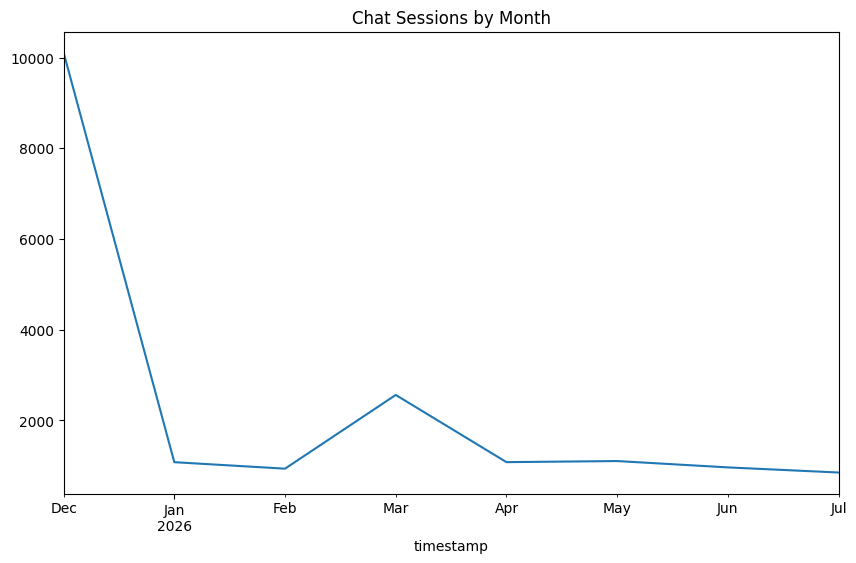

In [174]:
# Group by the Month/Year of the timestamp column
df_clean.groupby(df_clean['timestamp'].dt.to_period('M')).size().plot(kind='line', figsize=(10, 6), title='Chat Sessions by Month')

<Axes: xlabel='day_of_week'>

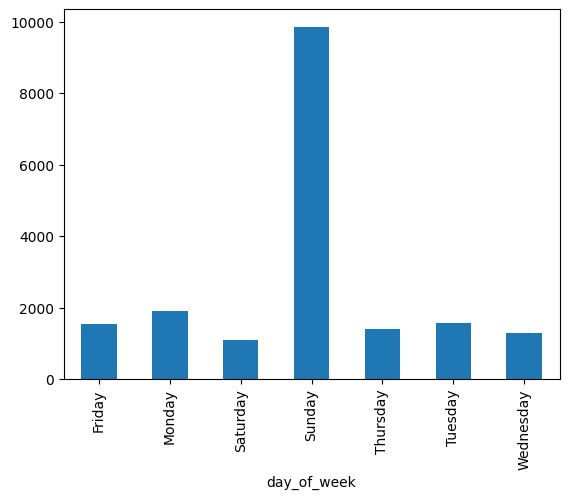

In [175]:
#Sessions by day of week
df_clean['day_of_week'].value_counts().sort_index().plot(kind='bar')
#Shows which day of the week users most interact with Sunny

<Axes: title={'center': 'Chat Sessions by Hour'}, xlabel='timestamp'>

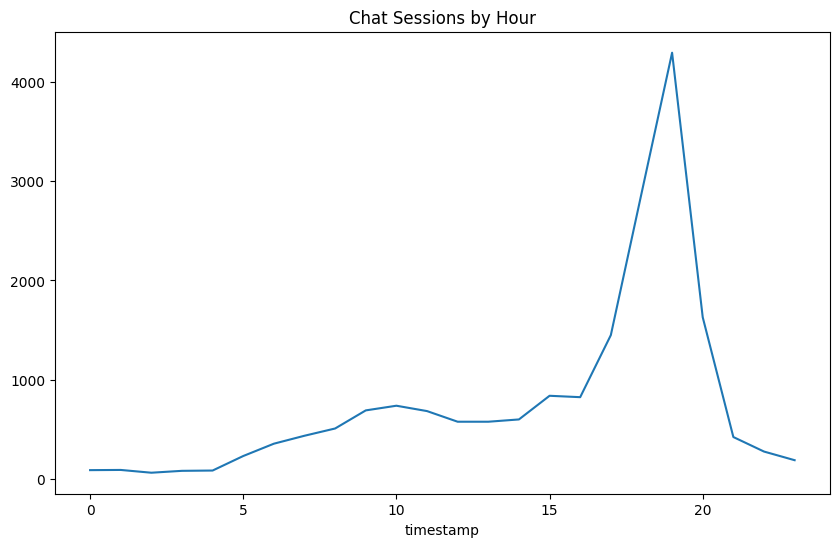

In [177]:
# Sessions by hour
df_clean['timestamp'].dt.hour.value_counts().sort_index().plot(kind='line', figsize=(10, 6), title='Chat Sessions by Hour')

# Time of day Sunny is most used

Operational performance

<Axes: ylabel='Frequency'>

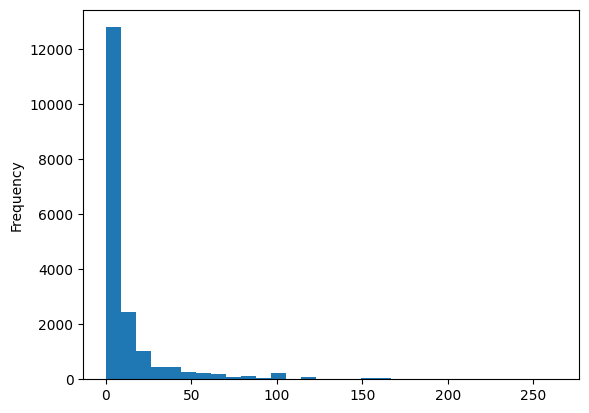

In [178]:
#Processing time distribution
df_clean['processing_time_seconds'].plot(kind='hist', bins=30)
#Look for outliers

<Axes: xlabel='total_tokens', ylabel='processing_time_seconds'>

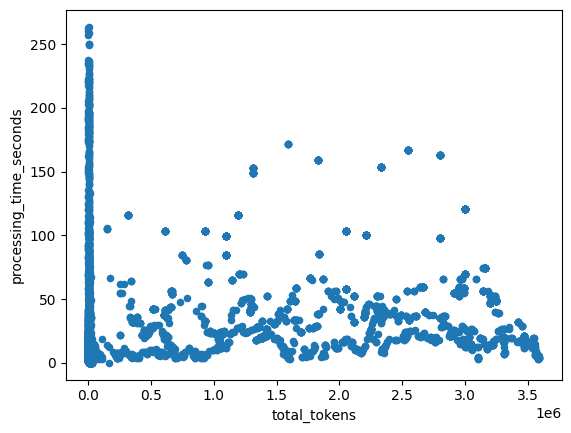

In [179]:
#Processing time vs total tokens
df_clean.plot(x='total_tokens', y='processing_time_seconds', kind='scatter')
#Shoes if using more tokens results in a longer procesing time

<Axes: xlabel='model_calls', ylabel='processing_time_seconds'>

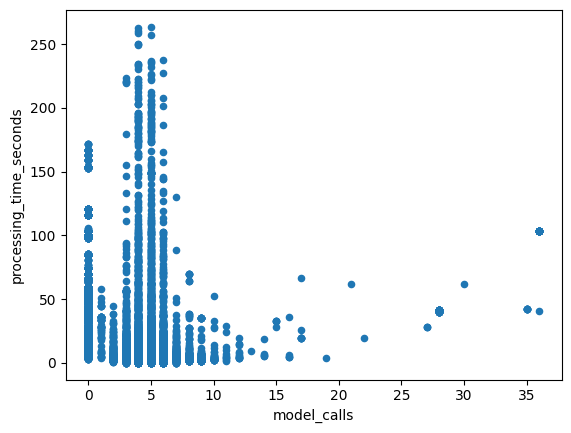

In [180]:
#Processing time vs model calls
df_clean.plot(x='model_calls', y='processing_time_seconds', kind='scatter')
#Shows whether additional model calls aare associated with slower responses

User Interest

<Axes: title={'center': 'Most Frequent Question Categories'}, ylabel='primary_category'>

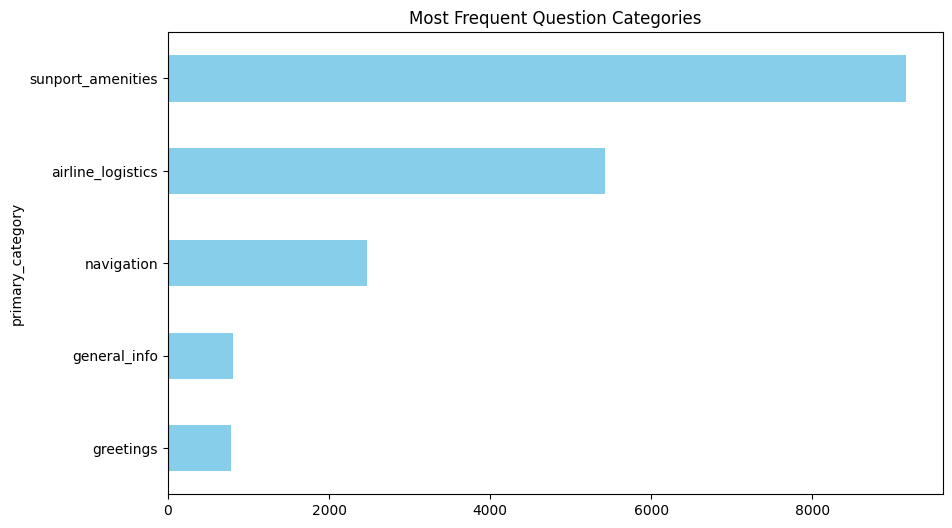

In [182]:
# Category frequency plot
df_clean['primary_category'].value_counts().sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Most Frequent Question Categories',
    color='skyblue'
)

# Answers what type of user questions are asked most often

<Axes: title={'center': 'Sessions Handled by Each Agent'}, ylabel='selected_agent'>

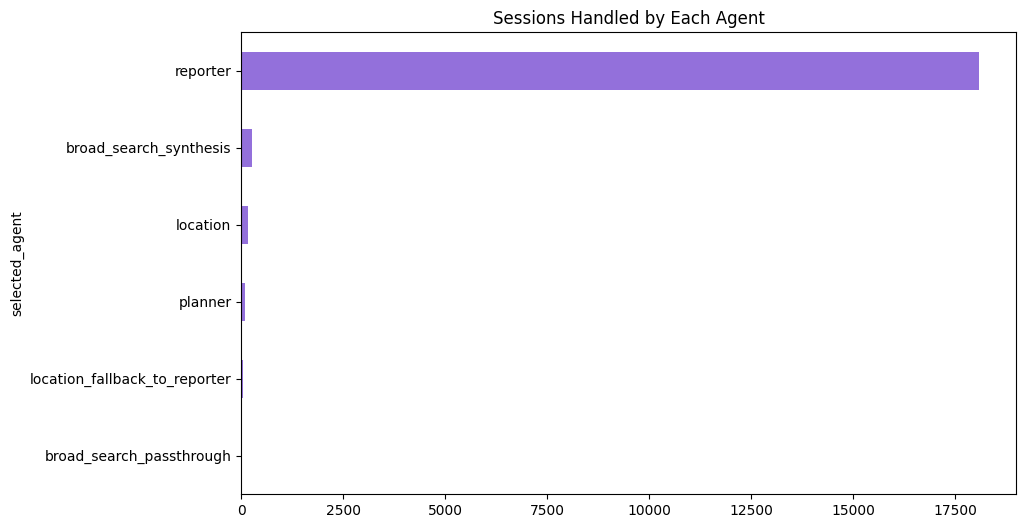

In [184]:
# Shows which agents handle the most sessions
df_clean['selected_agent'].value_counts().sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Sessions Handled by Each Agent',
    color='mediumpurple'
)

Satisfaction

<Axes: xlabel='star_rating'>

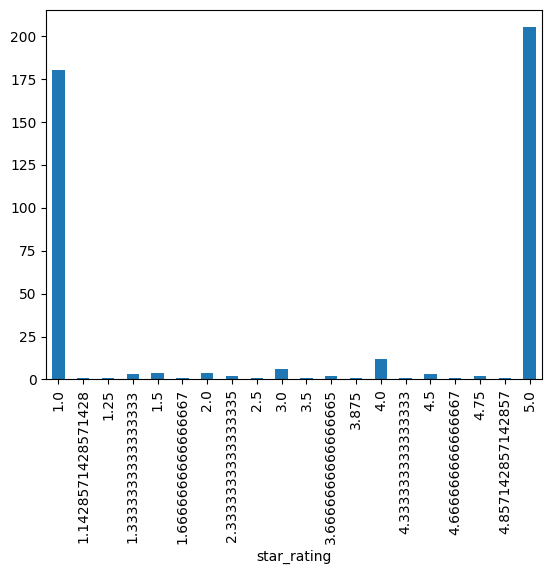

In [185]:
#Distribution of star ratings
df_rated['star_rating'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='star_rating'>

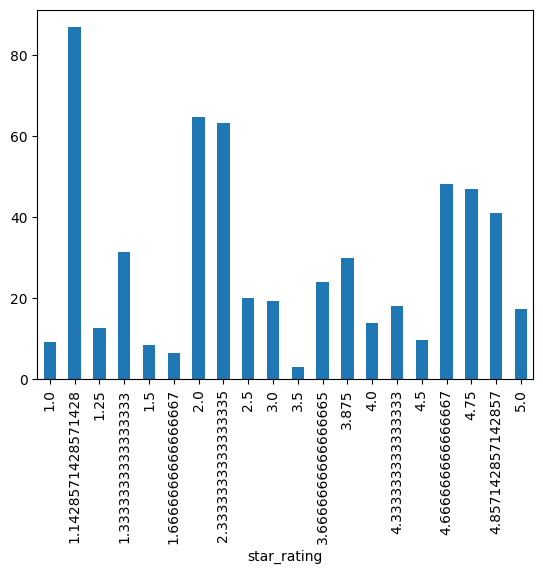

In [186]:
#Average processing time by star rating
df_rated.groupby('star_rating')['processing_time_seconds'].mean().plot(kind='bar')

<Axes: xlabel='star_rating'>

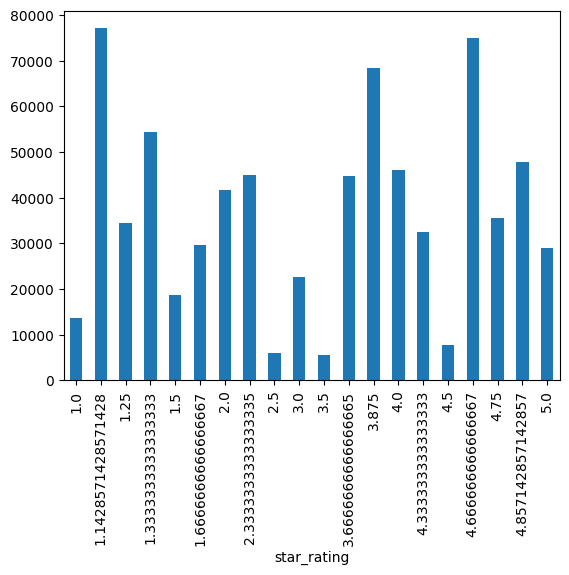

In [187]:
#Average tokens by star rating
df_rated.groupby('star_rating')['total_tokens'].mean().plot(kind='bar')
#Do highly rated interactions use more or fewer tokens

<Axes: xlabel='star_rating'>

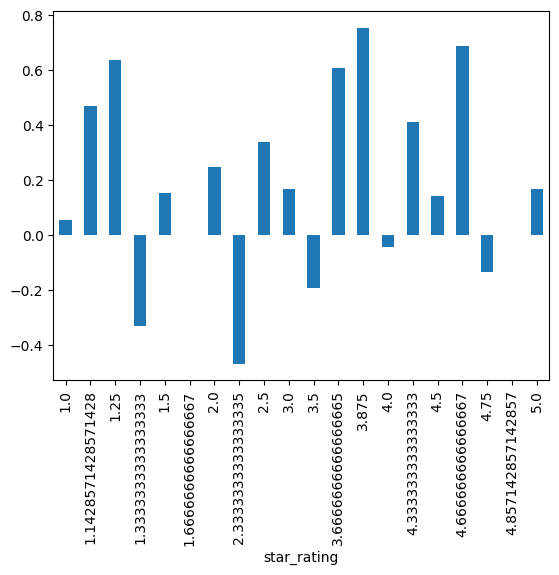

In [188]:
#Question
df_rated.groupby('star_rating')['question_sentiment'].mean().plot(kind='bar')

<Axes: xlabel='star_rating'>

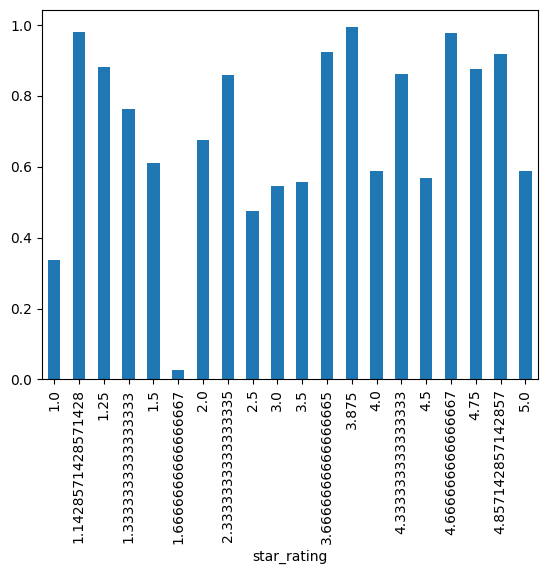

In [189]:
#Answer
df_rated.groupby('star_rating')['answer_sentiment'].mean().plot(kind='bar')

Histogram

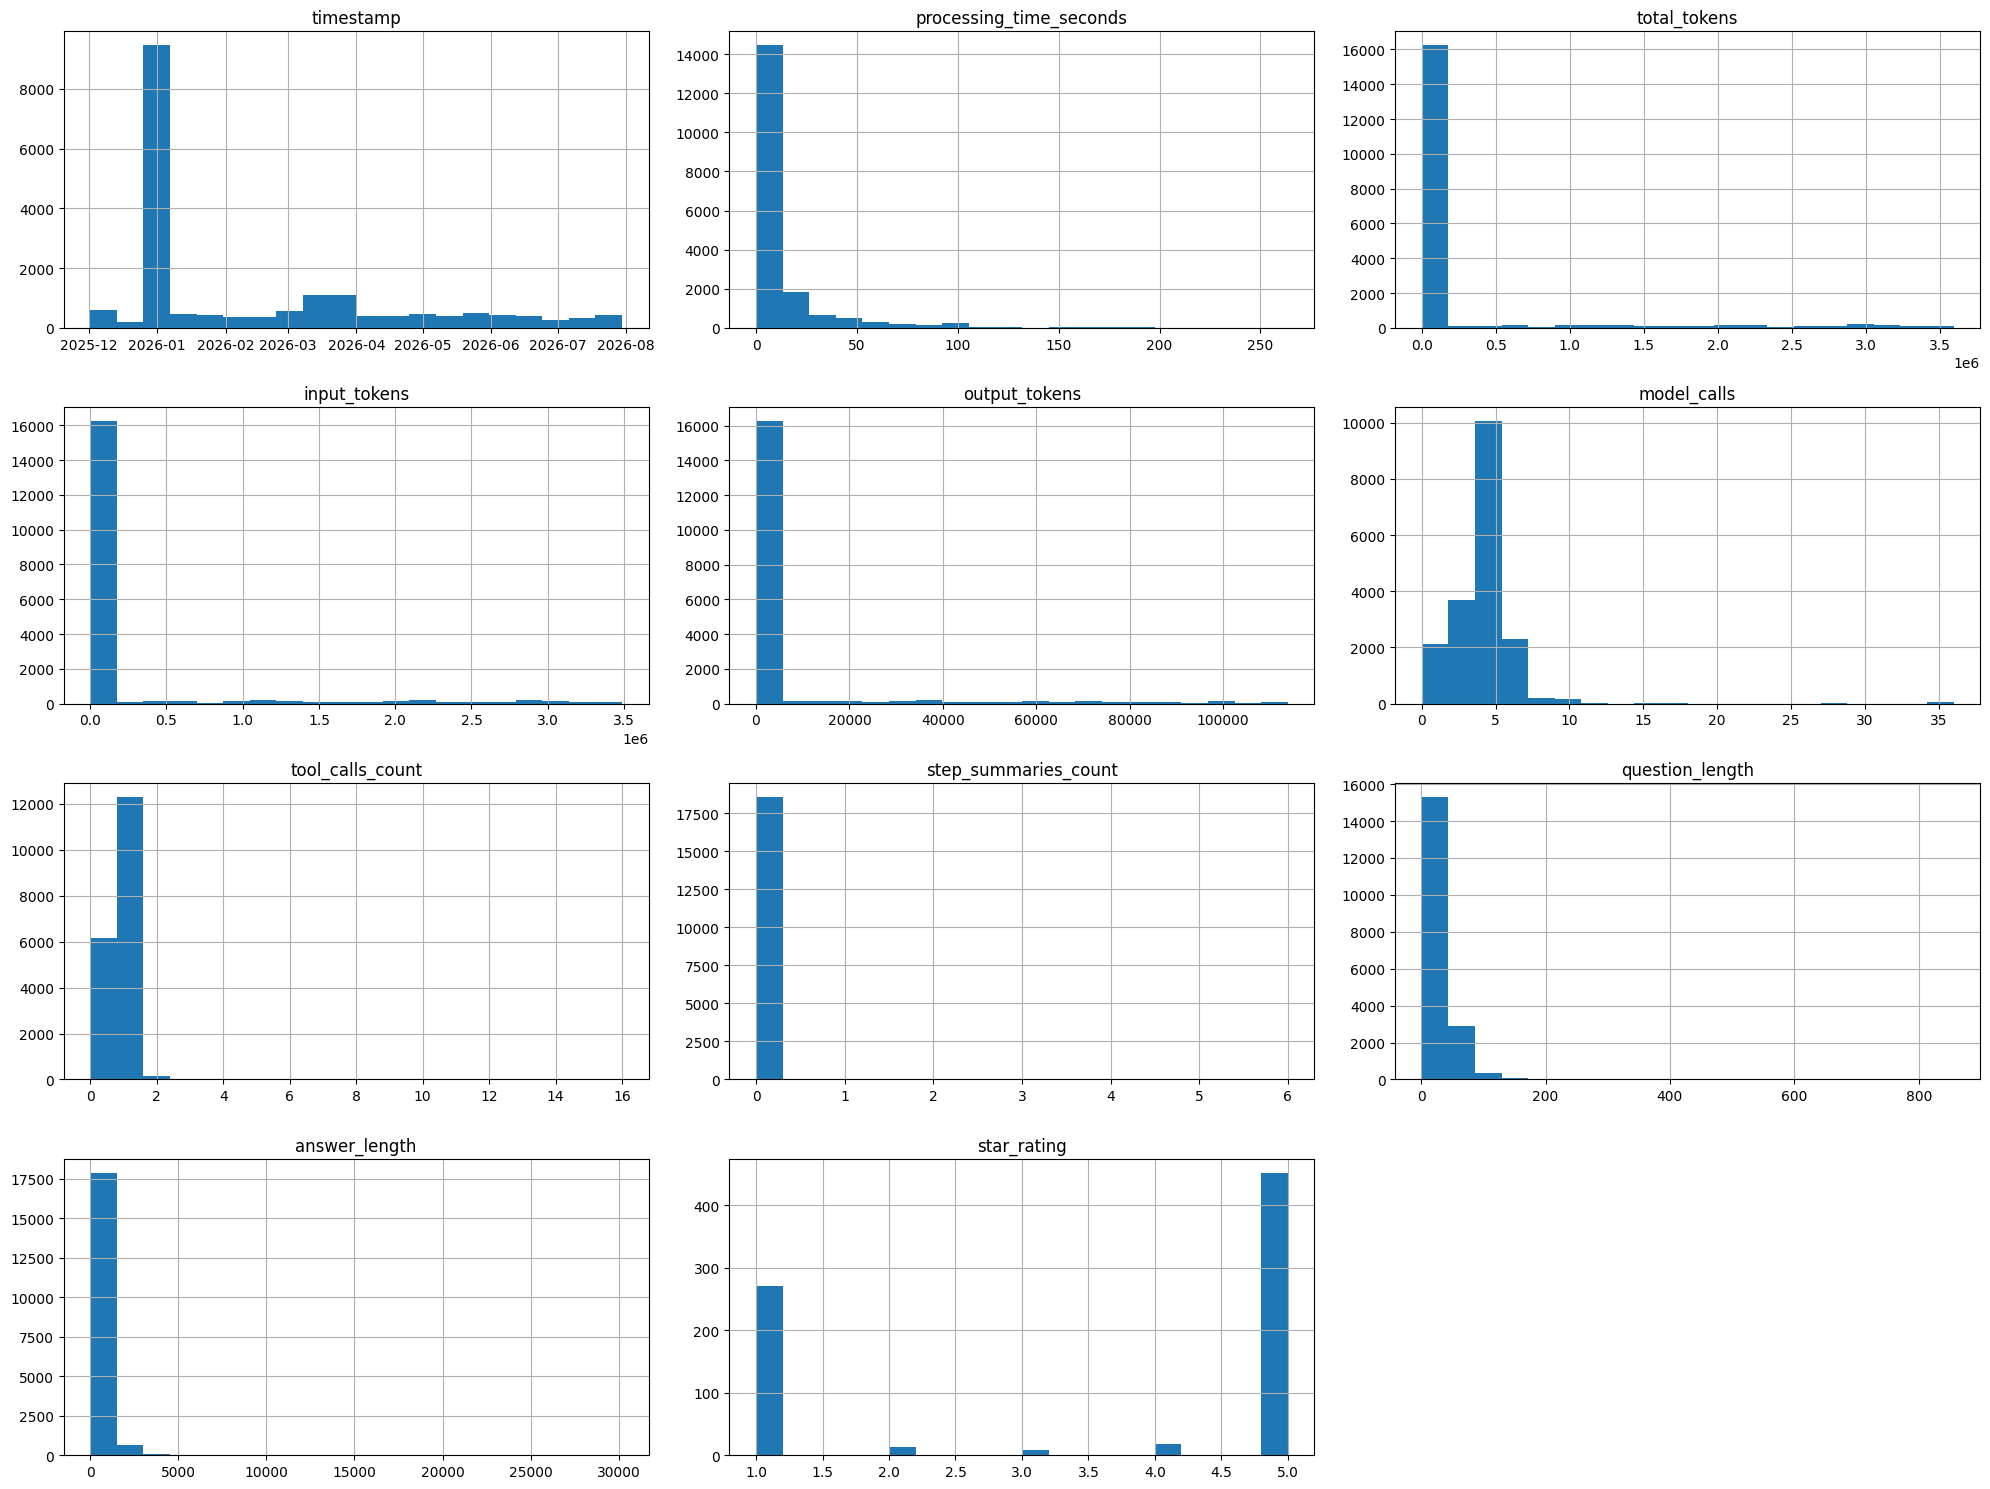

In [199]:
df_clean.hist(figsize=(20, 15), bins=20)

plt.tight_layout()
plt.show()

#ERD

In [201]:
import graphviz

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

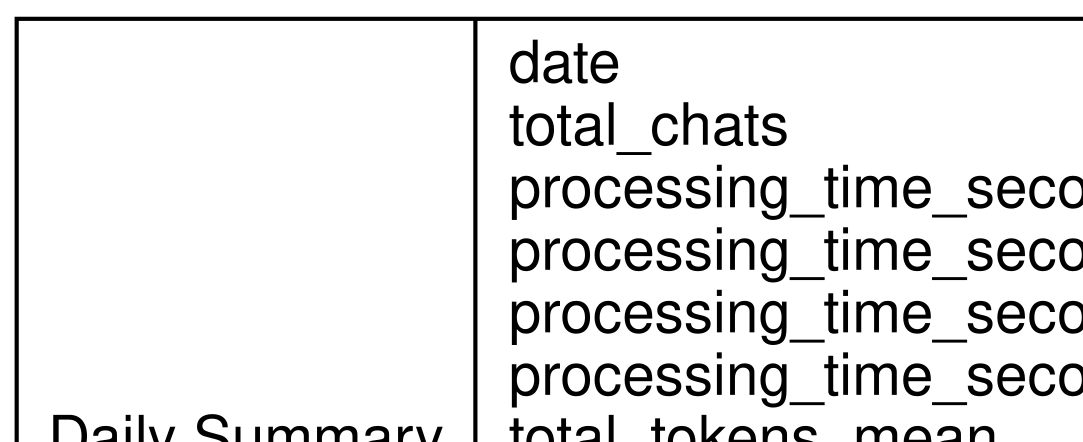

In [202]:
dfs = pd.read_excel(file_path, sheet_name=None)
df = dfs['Raw Data']
feedback = dfs['User Feedback']
performance = dfs['Performance']
daily_summary = dfs['Daily Summary']
category_distribution = dfs['Category Distribution']
hourly_pattern = dfs['Hourly Pattern']

# Create a new directed graph
# ADDED: 'rankdir': 'LR' makes it horizontal (better for slides)
# ADDED: 'dpi': '300' makes it high-resolution so it doesn't get blurry
erd = graphviz.Digraph('ERD',
                       node_attr={'shape': 'record', 'fontname': 'Helvetica'},
                       graph_attr={'rankdir': 'LR', 'dpi': '300'})

# Helper function to dynamically grab all columns from a dataframe
def get_columns_string(table_name, dataframe):
    cols = dataframe.columns.tolist()
    cols_str = r'\l'.join(cols) + r'\l'
    return f"{{{table_name} | {cols_str}}}"

# 1. Define tables (Entities) dynamically pulling ALL columns
erd.node('raw_data', get_columns_string('Raw Data (df)', df))
erd.node('feedback', get_columns_string('User Feedback', feedback))
erd.node('performance', get_columns_string('Performance', performance))
erd.node('daily_summary', get_columns_string('Daily Summary', daily_summary))
erd.node('category_distribution', get_columns_string('Category Distribution', category_distribution))
erd.node('hourly_pattern', get_columns_string('Hourly Pattern', hourly_pattern))

# 2. Define the relationships (Edges)
erd.edge('raw_data', 'feedback', label='chat_id')
erd.edge('raw_data', 'performance', label='chat_id')
erd.edge('daily_summary', 'raw_data', label='date')
erd.edge('category_distribution', 'raw_data', label='primary_category')
erd.edge('hourly_pattern', 'raw_data', label='hour')

# 3. Export and Download for your presentation
erd.format = 'png'
erd.render('chat_metrics_erd', view=False)
files.download('chat_metrics_erd.png')

# Display the ERD in the notebook
erd